In [1]:
# CELL 1 — Imports

import json
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

%matplotlib inline
sns.set_theme(style="whitegrid", rc={"figure.figsize": (8, 4.5)})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# CELL 2 — Constants, paths, and analysis parameters
#
# Paths are resolved from the repo root so this notebook runs the same whether
# launched from analysis/wards/ (its own directory) or from the repository root.


def _find_repo_root():
    here = os.getcwd()
    for candidate in (here, os.path.join(here, ".."), os.path.join(here, "..", "..")):
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "data")) and os.path.isdir(os.path.join(candidate, "analysis")):
            return candidate
    raise RuntimeError("Could not locate repo root (expected sibling 'data/' and 'analysis/' directories)")


REPO_ROOT = _find_repo_root()
DATA = os.path.join(REPO_ROOT, "data")
print(f"Repo root resolved to: {REPO_ROOT}")

# ---- census inputs ----
WARD_CENSUS_CSV = os.path.join(DATA, "census", "wards", "toronto-wards.csv")
WARD_NOC_NAICS_CSV = os.path.join(DATA, "census", "wards", "toronto-wards-noc-naics.csv")

# ---- activity inputs ----
ACTIVITY_DIR = os.path.join(DATA, "activity")
VENUE_STOPS_CSV = os.path.join(ACTIVITY_DIR, "venue_stops.csv")
VENUES_HOMES_CSV = os.path.join(ACTIVITY_DIR, "venues_homes.csv")
VENUES_HOMES_MONTHLY_CSV = os.path.join(ACTIVITY_DIR, "venues_homes_monthly.csv")
VENUES_REPEAT_VISITORS_CSV = os.path.join(ACTIVITY_DIR, "venues_repeat_visitors.csv")
VENUES_GEOHASH9_DIAGNOSTICS_CSV = os.path.join(ACTIVITY_DIR, "venues_geohash9_diagnostics.csv")
HOME_SAMPLE_INDEX_CSV = os.path.join(ACTIVITY_DIR, "home_sample_index.csv")
TORONTO_MONTH_DENOMS_CSV = os.path.join(ACTIVITY_DIR, "toronto_month_denoms.csv")
VENUE_METRICS_JSON = os.path.join(ACTIVITY_DIR, "venue_metrics.json")

WARDS_ACTIVITY_DIR = os.path.join(ACTIVITY_DIR, "wards")
WARD_TO_VENUE_ACTIVITY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_venue_activity.csv")
WARD_TO_VENUE_SUMMARY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_venue_summary.csv")
WARD_TO_WARD_ACTIVITY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_ward_activity.csv")
WARD_TO_WARD_SUMMARY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_ward_summary.csv")
WARD_TO_WARD_MATRIX_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_ward_matrix.csv")
WARD_BREAKDOWN_DIR = os.path.join(WARDS_ACTIVITY_DIR, "by_origin_ward")

# Verified TAC venue metadata (max_attendee_capacity, primary_discipline, ownership,
# tac_funded_operator/resident/programming) -- the ONLY funding/type metadata found in
# the repo that is directly keyed to the 105 study venues (via `id` <-> `venue_id`).
VENUE_CENTROIDS_GEOJSON = os.path.join(DATA, "venues", "tac-list", "venues-centroids.geojson")

# ---- analysis parameters ----
TIME_PERIOD = "all"  # never combine with weekday/weekend or nine-five/evening slices -- see Section 1
VALUE_COL = "normalized_raw_stop_count_by_ward"  # the ward-mapped, sample-normalized activity metric this study uses throughout
MERIDIAN_VENUE_NAMES = ["Meridian Arts Centre", "Meridian Hall"]  # both inspected; the Willowdale case study concerns the former

# The five custom NOC/NAICS cultural-workforce measures -- kept separate throughout;
# never summed (they slice on different, overlapping axes -- see Section 1).
NOC_NAICS_MEASURES = [
    "labour_creatives",
    "labour_cultural_workers",
    "labour_cultural_industries",
    "labour_independent_artists",
    "labour_arts_major",
]
NOC_NAICS_LABELS = {
    "labour_creatives": "Creatives (NOC)",
    "labour_cultural_workers": "Cultural workers (NOC)",
    "labour_cultural_industries": "Cultural industries (NAICS)",
    "labour_independent_artists": "Independent artists & arts orgs (NAICS)",
    "labour_arts_major": "Arts-major education (CIP)",
}

# A small, hypothesis-led set of general ward-census characteristics for Section 6 --
# picked to speak to the story questions (income, housing tenure, age, immigration,
# education, commuting, density), plus the two broader StatCan arts-adjacent fields
# used as a contrast to the custom measures. Not an exhaustive characteristic dump.
GENERAL_CENSUS_CHARACTERISTICS = {
    "income_total_median": "Median total income, 2020 ($)",
    "housing_tenure_renter": "Renter households (count)",
    "housing_tenure_total": "Total private households (for renter share)",
    "age_median": "Median age",
    "citizen_not_canadian": "Not Canadian citizens (count)",
    "citizen_total": "Total (for citizenship share)",
    "visible_minority_yes": "Visible minority population (count)",
    "visible_minority_total": "Total (for visible-minority share)",
    "education_bachelor_higher": "Bachelor's degree or higher, age 15+ (count)",
    "education_total": "Total, age 15+ (for education share)",
    "commute_mode_transit": "Commutes mainly by public transit (count)",
    "commute_mode_total": "Total commuters (for transit share)",
    "pop_density": "Population density (per km^2)",
    "labour_occupation_5_arts_culture": "Standard NOC: arts, culture, recreation & sport occupations (count)",
    "labour_occupation_total": "Total labour force by occupation (for occupation share)",
    "labour_industry_71_arts": "Standard NAICS 71: arts, entertainment & recreation industry (count)",
    "labour_industry_total": "Total labour force by industry (for industry share)",
}

# Case studies: Scarborough North and Willowdale are mandated contrasts. Eglinton-Lawrence
# and Don Valley West are added in Section 5 because Section 4C/4B surfaced them as genuinely
# useful comparisons (high cultural-workforce presence + low venue provision; extreme
# outside-ward share), not chosen a priori.
PRIMARY_CASE_STUDY_WARDS = ["Scarborough North", "Willowdale"]
ADDITIONAL_CASE_STUDY_WARDS = ["Eglinton-Lawrence", "Don Valley West"]
CASE_STUDY_WARDS = PRIMARY_CASE_STUDY_WARDS + ADDITIONAL_CASE_STUDY_WARDS

PALETTE = sns.color_palette("colorblind")

Repo root resolved to: /home/aniket/Programming/eddit-tac


# Toronto ward cultural infrastructure & activity: an exploration for city councillors

**Audience:** Toronto city councillors, especially those representing wards with less arts
infrastructure or less Toronto Arts Council (TAC) support.

**Objective:** identify a small number of defensible, evidence-based data-story angles about
ward-level cultural infrastructure, activity, and access -- built from (1) TAC's 105-venue
activity sample, (2) 2021 Census data for the 25 wards, and (3) a custom StatCan
cultural-workforce tabulation for the same wards.

**Approach:** every finding below is checked against the data before it is used to support a
story. Section 1 establishes exactly what each input measures (and, importantly, what it does
NOT measure). Section 2 checks comparability and flags influential observations. Sections 3-6
build the comparison table and investigate each candidate story angle in the priority order
requested. Section 7 closes with the recommended angles, explicitly separating **findings**
(what the data shows), **interpretations** (a plausible councillor-facing reading), and
**open questions** (what more evidence would be needed to strengthen the claim).

---

## Section 1 — What the data measures

We inspect three families of input before computing anything:

1. **General ward census file** (`toronto-wards.csv`) -- long-form 2021 Census Profile
   characteristics for the 25 wards, extracted in `analysis/census/extract_census_wards.ipynb`.
2. **Custom NOC/NAICS cultural-workforce file** (`toronto-wards-noc-naics.csv`) -- a custom
   StatCan tabulation of five distinct labour/education slices, interpolated to wards in the
   same notebook.
3. **Activity files** (`data/activity/`) -- TAC's mobility-derived venue visitation sample for
   105 arts/culture venues, produced by the notebooks under `analysis/activity/`.

### 1.1 General ward census file

Long-form: one row per (ward, characteristic). `analysis/census/extract_census_wards.ipynb`
pulls this from StatCan's federal-riding-level Census Profile product `98-401-X2021010` --
Toronto's 25 municipal wards were redrawn in 2018 to match the 25 federal ridings exactly, so
the join is exact, not approximate. `C1_COUNT_TOTAL` is the raw count; `C10_RATE_TOTAL` is
StatCan's own published rate/percentage for characteristics where one exists (mostly null for
raw counts).

In [3]:
# CELL — Load the general ward census file

ward_census_long = pd.read_csv(WARD_CENSUS_CSV, dtype={"ward_code": str}, encoding="latin1")
print(f"Rows: {len(ward_census_long)}  |  wards: {ward_census_long['ward_code'].nunique()}  "
      f"|  characteristics: {ward_census_long['CHARACTERISTIC_CODE'].nunique()}")
ward_census_long.head()

Rows: 4600  |  wards: 25  |  characteristics: 184


,ward_code,ward_name,GEO_NAME,CHARACTERISTIC_ID,CHARACTERISTIC_NAME,CHARACTERISTIC_CODE,C1_COUNT_TOTAL,C10_RATE_TOTAL
0,01,Etobicoke North,Etobicoke North,1,"Population, 2021",pop_2021,116003.0,NaN
1,01,Etobicoke North,Etobicoke North,2,"Population, 2016",pop_2016,118040.0,NaN
2,01,Etobicoke North,Etobicoke North,3,"Population percentage change, 2016 to 2021",pop_pct_change,-1.7,-1.7
3,01,Etobicoke North,Etobicoke North,6,Population density per square kilometre,pop_density,2428.3,2428.3
4,01,Etobicoke North,Etobicoke North,34,Total - Distribution (%) of the population by ...,age_total_dist,100.0,100.0


In [4]:
# CELL — Pivot to a wide (ward x characteristic) table for the small set of general
# characteristics we'll actually use in Section 6, keyed on CHARACTERISTIC_CODE

ward_census_wide = (
    ward_census_long[ward_census_long["CHARACTERISTIC_CODE"].isin(GENERAL_CENSUS_CHARACTERISTICS)]
    .pivot_table(index=["ward_code", "ward_name"], columns="CHARACTERISTIC_CODE", values="C1_COUNT_TOTAL")
    .reset_index()
)
print(f"General census fields captured: {[c for c in GENERAL_CENSUS_CHARACTERISTICS if c in ward_census_wide.columns]}")
missing = [c for c in GENERAL_CENSUS_CHARACTERISTICS if c not in ward_census_wide.columns]
assert not missing, f"expected characteristics missing from toronto-wards.csv: {missing}"
ward_census_wide.head(3)

General census fields captured: ['income_total_median', 'housing_tenure_renter', 'housing_tenure_total', 'age_median', 'citizen_not_canadian', 'citizen_total', 'visible_minority_yes', 'visible_minority_total', 'education_bachelor_higher', 'education_total', 'commute_mode_transit', 'commute_mode_total', 'pop_density', 'labour_occupation_5_arts_culture', 'labour_occupation_total', 'labour_industry_71_arts', 'labour_industry_total']


CHARACTERISTIC_CODE,ward_code,ward_name,age_median,citizen_not_canadian,citizen_total,commute_mode_total,commute_mode_transit,education_bachelor_higher,education_total,housing_tenure_renter,housing_tenure_total,income_total_median,labour_industry_71_arts,labour_industry_total,labour_occupation_5_arts_culture,labour_occupation_total,pop_density,visible_minority_total,visible_minority_yes
0,01,Etobicoke North,38.0,23535.0,115115.0,39265.0,8825.0,22120.0,96620.0,17340.0,38130.0,32400.0,820.0,57265.0,905.0,57265.0,2428.3,115120.0,90135.0
1,02,Etobicoke Centre,45.6,10925.0,117205.0,34180.0,5260.0,37540.0,99900.0,14780.0,45345.0,44400.0,1120.0,61275.0,2235.0,61275.0,3198.3,117205.0,37205.0
2,03,Etobicoke-Lakeshore,40.8,18790.0,139920.0,42490.0,9210.0,54175.0,121460.0,28260.0,65575.0,47600.0,1600.0,82950.0,4430.0,82950.0,3575.4,139915.0,48675.0


### 1.2 Custom NOC/NAICS cultural-workforce file

Wide, 25-row ward table. A **custom StatCan special tabulation** (order code `EO4126`),
not a standard published product. StatCan cross-tabulated population by three independent
axes at the **census-tract** level (`data/census/noc-naics/tac_census21/raw/`), which
TAC's pipeline then **areal-interpolated to wards** in `extract_census_wards.ipynb`
(population-weighted: tract *counts* are split by area overlap, then percentages are
recomputed at the ward level from the interpolated counts).

**Confirmed from the raw StatCan order files** (`"Selected NOCs, "` column, 6 literal values):

| Column here | StatCan's own label | Axis |
|---|---|---|
| `labour_creatives` | "NOC - Creatives" | Occupation (NOC) |
| `labour_cultural_workers` | "NOC - Cultural Workers" | Occupation (NOC) |
| `labour_cultural_industries` | "NAICS - Cultural Industries" | Industry (NAICS) |
| `labour_independent_artists` | "NAICS - Independent Artists + Arts Organizations" | Industry (NAICS) |
| `labour_arts_major` | "CIP — Arts Major" | Field of study (CIP) |

**Confirmed vs. undocumented:**

- **Confirmed:** these are StatCan's own pre-aggregated labels. No file in the repo (raw/clean
  CSVs, data dictionary, `.ivt` binaries, any notebook) lists the underlying NOC/NAICS/CIP
  codes. We name the 5 buckets exactly as StatCan labelled them and don't narrow their meaning
  beyond that plain-language label.
- **Confirmed -- universe is age 15+, not all ages.** The raw order's `Age (6)` column only
  has 15-24/25-44/45-64/65+ (no 0-14), and those bands sum exactly to the unfiltered Toronto
  CD total (2,377,945). This -- not a private-household restriction, for which no evidence
  exists either way -- explains the population-base gap vs. the general ward file (2.1).
- **Confirmed -- `_pct = count / pop_2021_count * 100`** (same-tract population total, per
  the data dictionary's `share_of_population` definition). We reuse the file's own published
  percentages rather than recomputing them against a different population field.
- **Confirmed -- the three axes are independent, not hierarchy tiers.** Each measure fixes one
  axis (`noc_group`/`naics_group`/`cip_group`) while the other two stay `all` -- a person in
  `labour_creatives` could simultaneously be in `labour_cultural_industries` and/or
  `labour_arts_major`. **These five measures may overlap and are never summed into a combined
  "creative population."** Mutual exclusivity *within* the NOC axis (creatives vs. cultural
  workers) is not explicitly stated, though a single categorical banner variable is StatCan's
  standard design for mutually-exclusive categories.
- **Undocumented -- residence vs. workplace.** No field says either way. Circumstantial
  evidence favours residence (crossed against home-address attributes like immigrant status
  and core housing need; a *different* dataset in this repo labels workplace variables
  explicitly when they occur, and this one doesn't). Treated as residence, flagged as inference.
- **Confirmed -- why counts (incl. `pop_2021_count`) look fractional.** Raw tract-level counts
  are all exact multiples of 5 (standard disclosure-control rounding) -- verified directly,
  zero exceptions. Fractions appear only after **our own** areal interpolation, which splits an
  integer tract count into fractional ward shares -- an artifact of that method, not sub-person
  StatCan precision.
- **Confirmed -- reference period.** 2021 Census throughout; no income/other-year field exists
  in this dataset. (Separately, the general ward file's `income_total_median`, used in Section 6,
  follows standard StatCan practice of referencing the prior calendar year, 2020.)
- **Confirmed -- rounding/suppression disclosure.** Dictionary documents a `value_suppressed`
  flag but states no rounding base or suppression threshold in prose; nearest-5 rounding is only
  observable empirically. Small tract counts carry real, if modest, rounding uncertainty.

We treat `pop_2021_count` here as **this dataset's own age-15+ population base**, used only to
reproduce its own published percentages -- not as a substitute for the general ward file's
all-ages population, which remains our authoritative population figure (Section 2.1).

In [5]:
# CELL — Load the custom NOC/NAICS ward file

ward_noc_naics = pd.read_csv(WARD_NOC_NAICS_CSV, dtype={"ward_code": str})
print(f"Rows: {len(ward_noc_naics)}  |  wards: {ward_noc_naics['ward_code'].nunique()}")
ward_noc_naics.head(3)

Rows: 25  |  wards: 25


,ward_code,ward_name,pop_2021_count,labour_creatives_count,labour_cultural_workers_count,labour_cultural_industries_count,labour_independent_artists_count,labour_arts_major_count,labour_creatives_pct,labour_cultural_workers_pct,labour_cultural_industries_pct,labour_independent_artists_pct,labour_arts_major_pct
0,01,Etobicoke North,97534.650127,344.579891,700.252677,825.730870,124.498434,1761.983531,0.4,0.7,0.8,0.1,1.8
1,02,Etobicoke Centre,99390.021043,975.371948,1832.418101,1533.500842,337.752790,3960.920034,1.0,1.8,1.5,0.3,4.0
2,03,Etobicoke-Lakeshore,106707.987019,2106.414632,3616.235401,2841.024347,621.277921,5887.014148,2.0,3.4,2.7,0.6,5.5


### 1.3 Activity data: acquisition context, verified against `analysis/activity/tac_venues_stops_homes.ipynb`

Mobility-derived device "stops" at 105 TAC-listed arts/culture venues, July 2023 - June 2026.
Before computing anything, we pin down what a row represents:

- **Stop exclusion:** raw stops longer than **8 hours** (`dwell_time_minutes <= 480`) are
  dropped before sessionization.
- **Sessionization ("visits"):** consecutive stops for the same (device, venue) merge into one
  **visit** if the gap is **<= 60 minutes** (`VISIT_MERGE_GAP_MINUTES = 60`), via a running max
  of prior stop-end times. **A visit can cross midnight** -- nothing resets at day boundaries --
  and the merged visit is itself capped at 8 hours. Its `time_period` tag is assigned from the
  **start** timestamp only, so an evening visit that runs past midnight keeps the "evening" tag
  for its whole duration; it is not split.
- **Geohash precision:** venues matched at **geohash9** (~5x5m, 80% coverage-threshold
  flood-fill footprint); home origins at the coarser **geohash6** (~600m x 1.2km).
- **`raw_stop_count`** = stop events; **`visit_count`** = sessionized visits; **`unique_devices`**
  = distinct devices. Different grains of the same activity -- additive across venues/months,
  but not interchangeable with each other or with "unique people" (device != person).
- **Two separate, deliberately different normalization systems:**
  - *Overall venue trend* (`venue_stops.csv`): one **Toronto-wide monthly** device-count ratio
    vs. the Jul-Dec 2023 baseline, applied to every venue that month --
    `normalized_raw_stop_count = raw_stop_count * baseline_total_unique_devices / current_total_unique_devices`.
  - *Home-origin breakdown* (`venues_homes*.csv`): a **geohash6-cell-specific** sample ratio,
    falling back to the citywide ratio when a cell's baseline sample is thin (< 30 devices;
    ~88% of rows use the cell-specific ratio, ~12% the fallback).
  - **Not interchangeable.** "Normalized" means adjusted for known device-panel variation, not
    calibrated to an independent population count -- it is not an attendance estimate.
- **`time_period` values:** exactly `all`, `weekdays`, `weekends`, `nine-five`, `evening`.
  `all = weekdays + weekends` (a true partition). `nine-five` (weekdays, 9am-4:59pm) and
  `evening` (any day, 5-10:59pm) are a **separate, overlapping, non-exhaustive** day-part axis:
  `nine-five` is weekday-only, `evening` runs 7 days/week, and hours 0-8/23 and weekend daytime
  are covered by neither. **We default to `time_period == "all"`, and never add `all` to another
  slice, or `weekdays`+`weekends` to `nine-five`+`evening`.**
- **Home-origin eligibility:** a device gets a home row only with a `HOME`-tagged recurring area,
  confidence >= 0.60, geohash6 inside Toronto; failing devices are **silently dropped, not
  zero-filled**. ~60% of venue-visiting devices match each month; the other ~40% are unassigned.
  **`venues_homes*` totals are therefore not expected to equal `venue_stops` totals** for the
  same venue-month -- different subset, different normalization.
- **Repeat visitation** (`venues_repeat_visitors.csv`) is computed within fixed half-years
  (`2023H2, 2024H1, 2024H2, 2025H1, 2025H2, 2026H1`) because device IDs reset periodically.
- **Absent rows mean no recorded activity for that key/period** -- no separate "confirmed zero"
  marker exists, so a missing row and a true zero are indistinguishable from the file alone; we
  treat both as "no measurable activity" and flag it explicitly where it matters (e.g. Jan 2026, 2.2).
- **Venue metadata exists and is genuine:** `venues-centroids.geojson` (joined via
  `id` <-> `venue_id`) carries `max_attendee_capacity`, `total_facility_area_sqft`,
  `primary_discipline`, `ownership`, `operator`, `year_opened`, and three **TAC funding flags**
  -- `tac_funded_operator`, `tac_funded_resident`, `tac_funded_programming` -- for 85 of 105
  venues (20 have none filled in). This is the only funding/type metadata tied 1:1 to the 105
  study venues, so it's the only basis for connecting a finding to funding status.

In [6]:
# CELL — Compact inventory of every activity table (grain, coverage, metrics, intended use)
# All of these represent the SAME underlying visitation data at different grains/exports --
# not additional independent observations.

activity_inventory = pd.DataFrame([
    dict(file="venue_stops.csv", grain="venue x year_month x time_period",
         coverage="202307-202606, 105 venues (coverage dips some months, see 2.2)",
         metrics="raw_stop_count, visit_count, unique_devices, normalized_raw_stop_count/visit_count/unique_devices",
         use="Overall venue-level trends over time (citywide-normalized)"),
    dict(file="venues_homes.csv", grain="home_geohash6 x venue x time_period (all-time roll-up)",
         coverage="All-time sum across 202307-202606, home-eligible subset only",
         metrics="raw_stop_count, visit_count, unique_devices, normalized_raw_stop_count/visit_count",
         use="Base table for ward-of-origin interpolation (ward_to_venue_activity etc.)"),
    dict(file="venues_homes_monthly.csv", grain="home_geohash6 x venue x year_month x time_period",
         coverage="202307-202606, home-eligible subset only",
         metrics="same as venues_homes.csv, monthly grain",
         use="Monthly origin-ward trends IF a verified geohash6->ward mapping is built (Section 4D)"),
    dict(file="venues_repeat_visitors.csv", grain="venue x half_year x time_period",
         coverage="2023H2-2026H1 (6 fixed half-years)",
         metrics="unique_devices, repeat_devices, repeat_device_prop, devices_3plus_visit_days, devices_2plus_active_months",
         use="Repeat-visitation rate per venue per half-year (device IDs reset across periods)"),
    dict(file="venues_geohash9_diagnostics.csv", grain="venue x geohash9 cell",
         coverage="16,381 rows, footprint cells for all 105 venues",
         metrics="coverage_fraction, geohash_venue_count, overlaps_other_venue",
         use="Footprint/coverage QA -- flags venues whose geohash9 cells collide with another venue"),
    dict(file="home_sample_index.csv", grain="year_month x home_geohash6",
         coverage="202307-202606, 47,052 rows",
         metrics="current/baseline sample, applied_sample_ratio, normalization_method (geohash6 vs toronto_fallback)",
         use="Underlying normalization weights for the home-origin breakdown"),
    dict(file="toronto_month_denoms.csv", grain="year_month x time_period",
         coverage="202307-202606",
         metrics="total_stop_count, total_unique_devices",
         use="Underlying Toronto-wide monthly denominator for overall venue-trend normalization"),
    dict(file="venue_metrics.json", grain="one record per venue (105)",
         coverage="All-time, derived from the tables above",
         metrics="monthly series, repeat_visitor_pct, weekday/weekend + nine-five/evening splits, home_origin_hhi, travel_distance_distribution",
         use="Pre-built per-venue summary metrics, incl. 2 genuinely new fields: home_origin_hhi and straight-line travel_distance_distribution"),
    dict(file="wards/ward_to_venue_activity.csv", grain="venue x ward (origin)",
         coverage="105 venues x 25 wards = 2,625 rows",
         metrics="normalized_raw_stop_count_by_ward (+ pct), home_ward flag = same-ward Boolean, venue_ward = destination ward",
         use="Full origin-ward breakdown per venue (areal-interpolated from venues_homes.csv)"),
    dict(file="wards/ward_to_venue_summary.csv", grain="venue (one row each)",
         coverage="105 rows",
         metrics="within/outside-ward split, pct_inside_ward/pct_outside_ward; home_ward here = the VENUE's own ward (different meaning than above!)",
         use="Per-venue within- vs. outside-ward reach"),
    dict(file="wards/ward_to_ward_activity.csv", grain="origin ward x destination ward",
         coverage="25 x 25 = 625 rows",
         metrics="normalized_raw_stop_count_by_ward, same_ward flag, pct_of_origin, pct_of_destination",
         use="Full ward-to-ward flow matrix (this notebook's main input for Section 4A/B)"),
    dict(file="wards/ward_to_ward_summary.csv", grain="ward (one row each, origin side)",
         coverage="25 rows",
         metrics="within/outside-ward split, pct_inside_ward/pct_outside_ward",
         use="Per-ward within- vs. outside-ward reach (origin side)"),
    dict(file="wards/ward_to_ward_matrix.csv", grain="origin ward x destination ward, pivoted wide",
         coverage="25x25",
         metrics="normalized_raw_stop_count_by_ward",
         use="Same data as ward_to_ward_activity.csv, wide -- convenient for heatmaps"),
    dict(file="wards/by_origin_ward/{code}.csv", grain="one file per origin ward, same columns as ward_to_ward_activity",
         coverage="25 files",
         metrics="same as ward_to_ward_activity.csv, filtered to one origin ward",
         use="Convenience slices for per-ward case studies (Section 5)"),
])
activity_inventory

,file,grain,coverage,metrics,use
0,venue_stops.csv,venue x year_month x time_period,"202307-202606, 105 venues (coverage dips some ...","raw_stop_count, visit_count, unique_devices, n...",Overall venue-level trends over time (citywide...
1,venues_homes.csv,home_geohash6 x venue x time_period (all-time ...,"All-time sum across 202307-202606, home-eligib...","raw_stop_count, visit_count, unique_devices, n...",Base table for ward-of-origin interpolation (w...
2,venues_homes_monthly.csv,home_geohash6 x venue x year_month x time_period,"202307-202606, home-eligible subset only","same as venues_homes.csv, monthly grain",Monthly origin-ward trends IF a verified geoha...
3,venues_repeat_visitors.csv,venue x half_year x time_period,2023H2-2026H1 (6 fixed half-years),"unique_devices, repeat_devices, repeat_device_...",Repeat-visitation rate per venue per half-year...
4,venues_geohash9_diagnostics.csv,venue x geohash9 cell,"16,381 rows, footprint cells for all 105 venues","coverage_fraction, geohash_venue_count, overla...",Footprint/coverage QA -- flags venues whose ge...
5,home_sample_index.csv,year_month x home_geohash6,"202307-202606, 47,052 rows","current/baseline sample, applied_sample_ratio,...",Underlying normalization weights for the home-...
6,toronto_month_denoms.csv,year_month x time_period,202307-202606,"total_stop_count, total_unique_devices",Underlying Toronto-wide monthly denominator fo...
7,venue_metrics.json,one record per venue (105),"All-time, derived from the tables above","monthly series, repeat_visitor_pct, weekday/we...","Pre-built per-venue summary metrics, incl. 2 g..."
8,wards/ward_to_venue_activity.csv,venue x ward (origin),"105 venues x 25 wards = 2,625 rows","normalized_raw_stop_count_by_ward (+ pct), hom...",Full origin-ward breakdown per venue (areal-in...
9,wards/ward_to_venue_summary.csv,venue (one row each),105 rows,"within/outside-ward split, pct_inside_ward/pct...",Per-venue within- vs. outside-ward reach


In [7]:
# CELL — Load the ward-level activity exports, renaming the ambiguous `home_ward` column
# on sight (its meaning differs between files -- see 1.3 / inventory above) and the two
# `pct_of_*` columns for clarity.

ward_to_venue_activity = pd.read_csv(WARD_TO_VENUE_ACTIVITY_CSV).rename(columns={
    "ward_name": "origin_ward", "venue_ward": "dest_ward", "home_ward": "is_home_ward",
    "normalized_raw_stop_count_by_ward_pct": "pct_of_venue_total",
})
ward_to_venue_summary = pd.read_csv(WARD_TO_VENUE_SUMMARY_CSV).rename(columns={"home_ward": "dest_ward"})
ward_to_ward_activity = pd.read_csv(WARD_TO_WARD_ACTIVITY_CSV).rename(columns={
    "ward_name": "origin_ward", "venue_ward": "dest_ward",
    "normalized_raw_stop_count_by_ward_pct_of_origin": "pct_of_origin",
    "normalized_raw_stop_count_by_ward_pct_of_destination": "pct_of_destination",
})
ward_to_ward_summary = pd.read_csv(WARD_TO_WARD_SUMMARY_CSV).rename(columns={"ward_name": "origin_ward"})
ward_to_ward_matrix = pd.read_csv(WARD_TO_WARD_MATRIX_CSV).rename(columns={"ward_name": "origin_ward"}).set_index("origin_ward")

for name, df in [("ward_to_venue_activity", ward_to_venue_activity), ("ward_to_venue_summary", ward_to_venue_summary),
                  ("ward_to_ward_activity", ward_to_ward_activity), ("ward_to_ward_summary", ward_to_ward_summary)]:
    print(f"{name}: {df.shape}")

ward_to_ward_activity.head(3)

ward_to_venue_activity: (2625, 9)
ward_to_venue_summary: (105, 9)
ward_to_ward_activity: (625, 6)
ward_to_ward_summary: (25, 5)


,origin_ward,dest_ward,normalized_raw_stop_count_by_ward,same_ward,pct_of_origin,pct_of_destination
0,Beaches-East York,Beaches-East York,1252.559473,True,0.351938,0.457774
1,Beaches-East York,Davenport,25.683012,False,0.007216,0.008660
2,Beaches-East York,Don Valley East,32.699201,False,0.009188,0.020211


In [8]:
# CELL — Load venue metadata (funding, discipline, ownership) -- plain pandas via the
# GeoJSON's `properties`, no geopandas needed since we only want the attribute table here.

with open(VENUE_CENTROIDS_GEOJSON) as f:
    _venues_raw = json.load(f)
venue_meta = pd.DataFrame([feat["properties"] for feat in _venues_raw["features"]])
venue_meta = venue_meta.rename(columns={"id": "venue_id"})
venue_meta["venue_id"] = venue_meta["venue_id"].astype(int)  # matches the int venue_id used throughout the activity tables

n_no_meta = venue_meta["primary_discipline"].isna().sum()
print(f"Venues: {len(venue_meta)}  |  with no metadata filled in: {n_no_meta}")
print(venue_meta[["tac_funded_operator", "tac_funded_resident", "tac_funded_programming"]].apply(lambda c: c.value_counts(dropna=False)))
venue_meta[["venue_id", "venue_name", "primary_discipline", "ownership", "max_attendee_capacity",
            "tac_funded_operator", "tac_funded_resident", "tac_funded_programming"]].head()

Venues: 105  |  with no metadata filled in: 20
       tac_funded_operator  tac_funded_resident  tac_funded_programming
False                   60                   55                       7
True                    25                   30                      78
None                    20                   20                      20


,venue_id,venue_name,primary_discipline,ownership,max_attendee_capacity,tac_funded_operator,tac_funded_resident,tac_funded_programming
0,88,The Village at Black Creek,None,None,NaN,None,None,None
1,89,Barry Zuckerman Amphitheatre (Earl Bales Park),None,None,NaN,None,None,None
2,90,Lee Lifeson Art Park Amphitheatre,None,None,NaN,None,None,None
3,91,Downsview Park (Festival Terrace),None,None,NaN,None,None,None
4,92,Downsview Park (Discovery Centre),None,None,NaN,None,None,None


---

## Section 2 — Comparability checks and influential observations

We check the things that could actually change the story: whether the two census files
agree on wards and population, whether the activity tables reconcile with each other,
whether a single venue or a single month is quietly driving a headline number.

### 2.1 Census joins

In [9]:
# CELL — Both census files: same 25 wards, ward_code <-> ward_name agreement

codes_a = set(ward_census_long[["ward_code", "ward_name"]].drop_duplicates().itertuples(index=False, name=None))
codes_b = set(ward_noc_naics[["ward_code", "ward_name"]].drop_duplicates().itertuples(index=False, name=None))

assert len(codes_a) == 25 and len(codes_b) == 25, (len(codes_a), len(codes_b))
assert codes_a == codes_b, f"ward_code/ward_name mismatch between files: {codes_a ^ codes_b}"
print("Both files agree on all 25 (ward_code, ward_name) pairs -- joining on ward_code is safe, "
      "ward_name serves as a validation field.")

Both files agree on all 25 (ward_code, ward_name) pairs -- joining on ward_code is safe, ward_name serves as a validation field.


In [10]:
# CELL — Compare the two population measures and pick one authoritative figure

pop_general = (
    ward_census_long[ward_census_long["CHARACTERISTIC_CODE"] == "pop_2021"]
    [["ward_code", "ward_name", "C1_COUNT_TOTAL"]]
    .rename(columns={"C1_COUNT_TOTAL": "pop_2021_general"})
)
pop_compare = pop_general.merge(
    ward_noc_naics[["ward_code", "pop_2021_count"]].rename(columns={"pop_2021_count": "pop_2021_noc_naics"}),
    on="ward_code",
)
pop_compare["diff"] = pop_compare["pop_2021_general"] - pop_compare["pop_2021_noc_naics"]
pop_compare["diff_pct"] = pop_compare["diff"] / pop_compare["pop_2021_general"]

total_general = pop_compare["pop_2021_general"].sum()
total_noc_naics = pop_compare["pop_2021_noc_naics"].sum()
print(f"General ward census (all ages):      {total_general:,.0f}")
print(f"NOC/NAICS file (age 15+ universe):   {total_noc_naics:,.0f}")
print(f"Citywide ratio (15+/all-ages):        {total_noc_naics/total_general:.1%}  "
      f"-- consistent with Toronto's age structure, per Section 1.2")
print(f"\nPer-ward diff_pct range: {pop_compare['diff_pct'].min():.1%} to {pop_compare['diff_pct'].max():.1%}")
pop_compare.sort_values("diff_pct").head(3)

General ward census (all ages):      2,794,356
NOC/NAICS file (age 15+ universe):   2,362,498
Citywide ratio (15+/all-ages):        84.5%  -- consistent with Toronto's age structure, per Section 1.2

Per-ward diff_pct range: 4.4% to 24.7%


,ward_code,ward_name,pop_2021_general,pop_2021_noc_naics,diff,diff_pct
9,10,Spadina-Fort York,136213.0,130271.658243,5941.341757,0.043618
12,13,Toronto Centre,119901.0,107399.762122,12501.237878,0.104263
17,18,Willowdale,118218.0,103664.171650,14553.828350,0.123110


**Choice: `pop_2021_general` (all-ages population from the general ward census file) is our
authoritative population figure** for every per-capita calculation in this notebook (venues
per 100,000 residents, activity per resident, etc.). It is the standard, all-ages 2021 Census
population, matches how population is normally reported, and is not tied to the narrower
age-15+ universe of the custom NOC/NAICS file. We keep `pop_2021_noc_naics` only as the
denominator for reproducing that file's own published percentages (below) -- we do not use it
for anything else, and we do not recompute the NOC/NAICS `_pct` fields against
`pop_2021_general` instead.

In [11]:
# CELL — Confirm the custom file's own published percentages reproduce from pop_2021_count
# (its own denominator, per the data dictionary) -- we do NOT recompute them from a
# different population field, this is purely a self-consistency check.

max_pct_check_diff = 0.0
for measure in NOC_NAICS_MEASURES:
    recomputed = 100 * ward_noc_naics[f"{measure}_count"] / ward_noc_naics["pop_2021_count"]
    diff = (recomputed - ward_noc_naics[f"{measure}_pct"]).abs().max()
    max_pct_check_diff = max(max_pct_check_diff, diff)
    print(f"{measure:32s} max |recomputed_pct - published_pct| = {diff:.3f} pp")

assert max_pct_check_diff < 0.1, "published pct fields don't reproduce from pop_2021_count -- denominator assumption wrong"
print("\nAll 5 measures reproduce from pop_2021_count within rounding -- confirms the file's own denominator.")

labour_creatives                 max |recomputed_pct - published_pct| = 0.047 pp
labour_cultural_workers          max |recomputed_pct - published_pct| = 0.049 pp
labour_cultural_industries       max |recomputed_pct - published_pct| = 0.050 pp
labour_independent_artists       max |recomputed_pct - published_pct| = 0.047 pp
labour_arts_major                max |recomputed_pct - published_pct| = 0.047 pp

All 5 measures reproduce from pop_2021_count within rounding -- confirms the file's own denominator.


In [12]:
# CELL — Missingness / unexpected zeros in both census files

print("General ward census file -- nulls in C1_COUNT_TOTAL for our selected characteristics:")
print(ward_census_long[ward_census_long["CHARACTERISTIC_CODE"].isin(GENERAL_CENSUS_CHARACTERISTICS)]
      .groupby("CHARACTERISTIC_CODE")["C1_COUNT_TOTAL"].apply(lambda s: s.isna().sum()).loc[lambda s: s > 0])

print("\nNOC/NAICS file -- nulls per column:")
print(ward_noc_naics.isna().sum().loc[lambda s: s > 0])

print("\nNOC/NAICS file -- any exact zeros in count fields (plausible for small wards, but worth eyeballing):")
zero_counts = (ward_noc_naics[[f"{m}_count" for m in NOC_NAICS_MEASURES]] < 0.5).sum()
print(zero_counts)

General ward census file -- nulls in C1_COUNT_TOTAL for our selected characteristics:
Series([], Name: C1_COUNT_TOTAL, dtype: int64)

NOC/NAICS file -- nulls per column:
Series([], dtype: int64)

NOC/NAICS file -- any exact zeros in count fields (plausible for small wards, but worth eyeballing):
labour_creatives_count              0
labour_cultural_workers_count       0
labour_cultural_industries_count    0
labour_independent_artists_count    0
labour_arts_major_count             0
dtype: int64


### 2.2 Activity checks

Keys, duplicates, reconciliation between the venue-grain and ward-grain exports, and the
gap between "mapped to a ward" and "eligible home-origin" totals.

In [13]:
# CELL — Key/duplicate/completeness checks on the ward-grain activity exports

n_venues = ward_to_venue_summary["venue_id"].nunique()
print(f"Distinct venues: {n_venues}")

assert len(ward_to_venue_activity) == n_venues * 25, "expected a dense venue x ward cross-join"
assert ward_to_venue_activity.duplicated(["venue_id", "origin_ward"]).sum() == 0
assert set(ward_to_venue_activity["origin_ward"].unique()) == set(pop_general["ward_name"]), "all 25 wards must appear as origins for every venue"

assert len(ward_to_ward_activity) == 25 * 25, "expected a dense 25x25 ward x ward cross-join"
assert ward_to_ward_activity.duplicated(["origin_ward", "dest_ward"]).sum() == 0
assert set(ward_to_ward_activity["origin_ward"].unique()) == set(ward_to_ward_activity["dest_ward"].unique()) == set(pop_general["ward_name"])

assert len(ward_to_ward_summary) == 25 and ward_to_ward_summary["origin_ward"].is_unique
assert len(ward_to_venue_summary) == n_venues and ward_to_venue_summary["venue_id"].is_unique

print("All 25 wards retained everywhere (no silent drops); no duplicate keys; both cross-joins are fully dense.")

Distinct venues: 105
All 25 wards retained everywhere (no silent drops); no duplicate keys; both cross-joins are fully dense.


In [14]:
# CELL — Reconcile venue-grain and ward-grain summaries against their own full breakdowns

# (a) ward_to_venue_summary's within/outside split should equal ward_to_venue_activity's
# same-ward vs. other-ward rows, summed per venue
check_a = ward_to_venue_activity.groupby("venue_id").apply(
    lambda g: pd.Series({
        "within_check": g.loc[g["is_home_ward"], VALUE_COL].sum(),
        "outside_check": g.loc[~g["is_home_ward"], VALUE_COL].sum(),
    }),
    include_groups=False,
).reset_index()
check_a = check_a.merge(ward_to_venue_summary[["venue_id", f"{VALUE_COL}_within_ward", f"{VALUE_COL}_outside_ward"]], on="venue_id")
max_diff_a = (check_a["within_check"] - check_a[f"{VALUE_COL}_within_ward"]).abs().max()
print(f"(a) venue within-ward reconstruction, max abs diff: {max_diff_a:.6f}")
assert max_diff_a < 1e-6

# (b) ward_to_ward_summary's within/outside split should equal ward_to_ward_activity's
# same_ward vs. other rows, summed per origin ward
# NOTE: ward_to_ward_summary.csv's own columns are named WITHOUT the "_by_ward" infix
# (normalized_raw_stop_count_within_ward), unlike ward_to_venue_summary.csv's
# (normalized_raw_stop_count_by_ward_within_ward) -- confirmed by inspecting the raw
# CSV header directly; not a typo here.
check_b = ward_to_ward_activity.groupby(["origin_ward", "same_ward"])[VALUE_COL].sum().unstack("same_ward")
check_b = check_b.rename(columns={True: "within_check", False: "outside_check"}).reset_index()
check_b = check_b.merge(ward_to_ward_summary, on="origin_ward")
max_diff_b = (check_b["within_check"] - check_b["normalized_raw_stop_count_within_ward"]).abs().max()
print(f"(b) ward within-ward reconstruction, max abs diff: {max_diff_b:.6f}")
assert max_diff_b < 1e-6

# (c) ward_to_ward_activity, aggregated across origins per destination, should equal
# ward_to_venue_activity aggregated across venues per destination ward (both describe
# "activity received by venues in ward X", just at different source-table grains)
by_dest_from_ww = ward_to_ward_activity.groupby("dest_ward")[VALUE_COL].sum()
by_dest_from_wv = ward_to_venue_activity.groupby("dest_ward")[VALUE_COL].sum()
max_diff_c = (by_dest_from_ww - by_dest_from_wv).abs().max()
print(f"(c) destination totals, ward_to_ward vs ward_to_venue aggregated, max abs diff: {max_diff_c:.6f}")
assert max_diff_c < 1e-6

print("\nAll reconciliations pass -- the ward-grain summaries are simple roll-ups of the full breakdowns, no double-counting.")

(a) venue within-ward reconstruction, max abs diff: 0.000000


(b) ward within-ward reconstruction, max abs diff: 0.000000
(c) destination totals, ward_to_ward vs ward_to_venue aggregated, max abs diff: 0.000000

All reconciliations pass -- the ward-grain summaries are simple roll-ups of the full breakdowns, no double-counting.


In [15]:
# CELL — Compare the ward-mapped total against the eligible home-origin total it was built from

venues_homes = pd.read_csv(VENUES_HOMES_CSV)
homes_all = venues_homes[venues_homes["time_period"] == TIME_PERIOD]

eligible_total = homes_all["normalized_raw_stop_count"].sum()
mapped_total = ward_to_venue_activity[VALUE_COL].sum()
unmapped = eligible_total - mapped_total

print(f"Eligible home-origin total (venues_homes.csv, time_period='all'): {eligible_total:,.1f}")
print(f"Ward-mapped total (ward_to_venue_activity.csv, summed):           {mapped_total:,.1f}")
print(f"Unmapped remainder:                                                {unmapped:,.1f}  ({unmapped/eligible_total:.2%})")
print("\n(Expected to be small and positive: a home geohash6 cell can straddle the city boundary and lose a")
print(" sliver of area outside all 25 ward polygons during areal interpolation -- same mechanism documented")
print(" in extract_census_wards.ipynb's own ward-overlap/coverage check. This is NOT the ~40% home-eligibility")
print(" gap from Section 1.3 -- that gap is already 'used up' before venues_homes.csv even exists.)")

Eligible home-origin total (venues_homes.csv, time_period='all'): 116,008.0
Ward-mapped total (ward_to_venue_activity.csv, summed):           115,058.2
Unmapped remainder:                                                949.8  (0.82%)

(Expected to be small and positive: a home geohash6 cell can straddle the city boundary and lose a
 sliver of area outside all 25 ward polygons during areal interpolation -- same mechanism documented
 in extract_census_wards.ipynb's own ward-overlap/coverage check. This is NOT the ~40% home-eligibility
 gap from Section 1.3 -- that gap is already 'used up' before venues_homes.csv even exists.)


#### Venue-month coverage: the January 2026 dip

An initial pass over `venue_stops.csv` found only 69 of 105 venues with an `all`-period
record in January 2026, vs. roughly 93-101 in surrounding months. We check this before
treating it as evidence of a citywide decline.

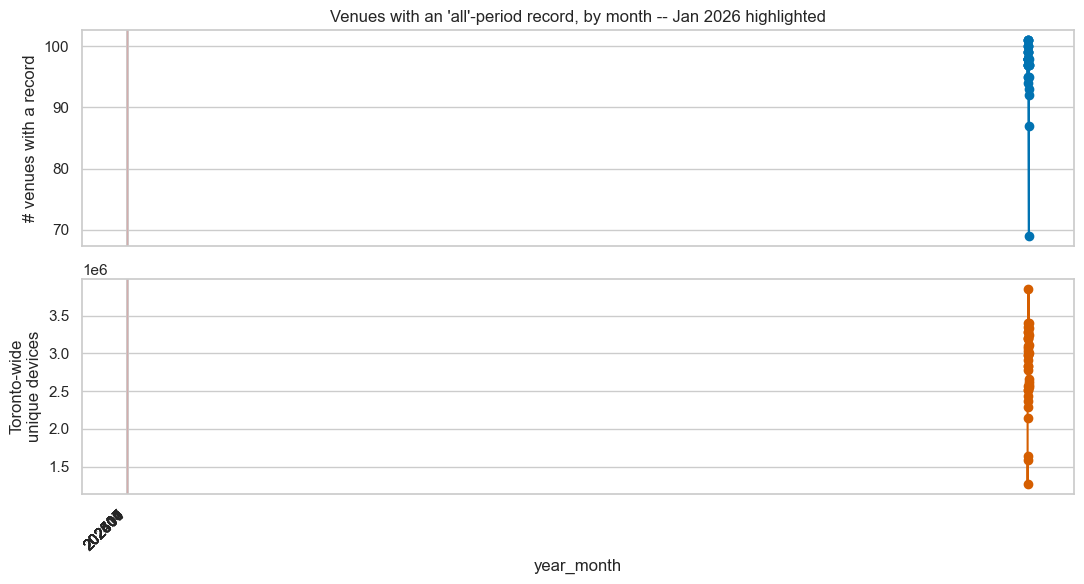

Jan 2026 venues: 69  |  Dec 2025: 93  |  Feb 2026: 87
Jan 2026 Toronto unique devices: 2,616,817  |  Dec 2025: 3,106,005  |  Feb 2026: 2,583,378


In [16]:
# CELL — Reproduce the venue-month coverage series and the Jan 2026 dip

venue_stops = pd.read_csv(VENUE_STOPS_CSV)
vs_all = venue_stops[venue_stops["time_period"] == TIME_PERIOD]

venues_per_month = vs_all.groupby("year_month")["venue_id"].nunique()
month_denoms = pd.read_csv(TORONTO_MONTH_DENOMS_CSV)
denoms_all = month_denoms[month_denoms["time_period"] == TIME_PERIOD].set_index("year_month")["total_unique_devices"]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
venues_per_month.plot(ax=axes[0], marker="o", color=PALETTE[0])
axes[0].axvspan(venues_per_month.index.get_loc(202601) - 0.5, venues_per_month.index.get_loc(202601) + 0.5, color="red", alpha=0.15)
axes[0].set_ylabel("# venues with a record")
axes[0].set_title("Venues with an 'all'-period record, by month -- Jan 2026 highlighted")

denoms_all.reindex(venues_per_month.index).plot(ax=axes[1], marker="o", color=PALETTE[3])
axes[1].axvspan(venues_per_month.index.get_loc(202601) - 0.5, venues_per_month.index.get_loc(202601) + 0.5, color="red", alpha=0.15)
axes[1].set_ylabel("Toronto-wide\nunique devices")
axes[1].set_xlabel("year_month")
for ax in axes:
    ax.set_xticks(range(0, len(venues_per_month), 3))
    ax.set_xticklabels(venues_per_month.index[::3], rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Jan 2026 venues: {venues_per_month.loc[202601]}  |  Dec 2025: {venues_per_month.loc[202512]}  |  Feb 2026: {venues_per_month.loc[202602]}")
print(f"Jan 2026 Toronto unique devices: {denoms_all.loc[202601]:,.0f}  |  Dec 2025: {denoms_all.loc[202512]:,.0f}  "
      f"|  Feb 2026: {denoms_all.loc[202602]:,.0f}")

In [17]:
# CELL — Which venues are missing in Jan 2026, and are they just low-traffic?

venues_dec = set(vs_all.loc[vs_all["year_month"] == 202512, "venue_id"])
venues_jan = set(vs_all.loc[vs_all["year_month"] == 202601, "venue_id"])
missing_jan = venues_dec - venues_jan

venue_month_traffic = vs_all.groupby("venue_id")["raw_stop_count"].mean()
print(f"Venues present in Dec 2025 but missing in Jan 2026: {len(missing_jan)}")
print(f"  Mean monthly raw_stop_count -- missing set:  {venue_month_traffic.loc[list(missing_jan)].mean():.1f} "
      f"(median {venue_month_traffic.loc[list(missing_jan)].median():.1f})")
other_venues = set(vs_all["venue_id"].unique()) - missing_jan
print(f"  Mean monthly raw_stop_count -- all other venues: {venue_month_traffic.loc[list(other_venues)].mean():.1f} "
      f"(median {venue_month_traffic.loc[list(other_venues)].median():.1f})")

months_present = vs_all.groupby("venue_id")["year_month"].nunique()
print(f"\nOf the {len(missing_jan)} venues missing in Jan 2026, how many months (of 36) do they typically appear in?")
print(f"  Missing-in-Jan set:   median {months_present.loc[list(missing_jan)].median():.0f} months present")
print(f"  All other venues:     median {months_present.loc[list(other_venues)].median():.0f} months present")

Venues present in Dec 2025 but missing in Jan 2026: 27
  Mean monthly raw_stop_count -- missing set:  42.5 (median 8.7)
  Mean monthly raw_stop_count -- all other venues: 81.5 (median 18.5)

Of the 27 venues missing in Jan 2026, how many months (of 36) do they typically appear in?
  Missing-in-Jan set:   median 34 months present
  All other venues:     median 36 months present


**Finding:** the January 2026 dip is a real, citywide sample dip (Toronto-wide unique
devices fell ~16% from December to January -- 3.11M to 2.62M -- a swing similar in size to
February's recovery, 2.58M) that disproportionately pushed already lower-traffic venues
below the "at least one recorded stop this month" floor: the 27 venues missing in January
2026 average less than half the monthly raw stop count of the other 78 (median 8.7 vs.
18.5), yet most of them (median 34 of 36 months present) otherwise have near-complete
coverage -- consistent with an isolated one-month gap for most of these venues, not a
late addition or a permanent dropout. It is not a data-acquisition cutoff either (coverage
recovers normally from February onward). **We therefore do not read the January 2026 dip
as evidence of an activity decline**, and we avoid drawing month-over-month conclusions
from single months without checking coverage first (Section 4D uses matched-period
comparisons for this reason).

Normalization method share, by ROW COUNT (month x home-cell):
normalization_method
geohash6            0.878
toronto_fallback    0.122
Name: proportion, dtype: float64

Normalization method share, by SAMPLE VOLUME (current_sample, i.e. weighted by activity):
normalization_method
geohash6            0.996
toronto_fallback    0.004
Name: current_sample, dtype: float64


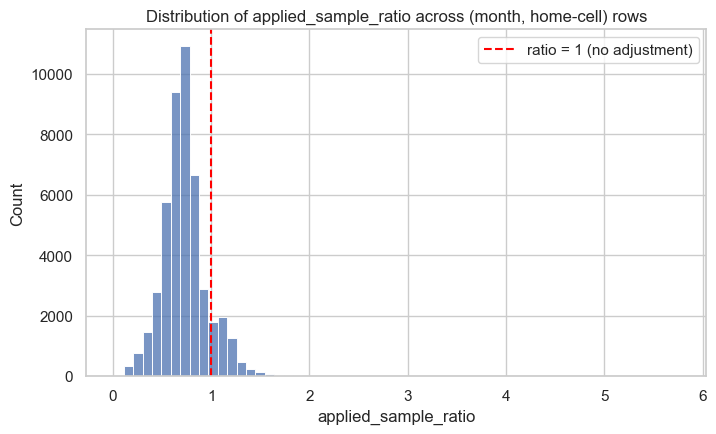

applied_sample_ratio: median 0.71, P10-P90 range 0.48-1.05


In [18]:
# CELL — Normalization weights: fallback use and ratio variability, weighted by actual
# contribution to activity (not just row counts, since a handful of cells carry most volume)

home_sample_index = pd.read_csv(HOME_SAMPLE_INDEX_CSV)

method_by_rows = home_sample_index["normalization_method"].value_counts(normalize=True)
weighted = home_sample_index.groupby("normalization_method")["current_sample"].sum()
method_by_volume = weighted / weighted.sum()

print("Normalization method share, by ROW COUNT (month x home-cell):")
print(method_by_rows.round(3))
print("\nNormalization method share, by SAMPLE VOLUME (current_sample, i.e. weighted by activity):")
print(method_by_volume.round(3))

fig, ax = plt.subplots()
sns.histplot(home_sample_index["applied_sample_ratio"], bins=60, ax=ax)
ax.set_title("Distribution of applied_sample_ratio across (month, home-cell) rows")
ax.set_xlabel("applied_sample_ratio")
ax.axvline(1.0, color="red", linestyle="--", label="ratio = 1 (no adjustment)")
ax.legend()
plt.show()
print(f"applied_sample_ratio: median {home_sample_index['applied_sample_ratio'].median():.2f}, "
      f"P10-P90 range {home_sample_index['applied_sample_ratio'].quantile(0.1):.2f}-{home_sample_index['applied_sample_ratio'].quantile(0.9):.2f}")

In [19]:
# CELL — Footprint coverage diagnostics: any venues whose geohash9 cells collide with
# another venue, and which venues have unusually large/dominant footprints

geohash9_diag = pd.read_csv(VENUES_GEOHASH9_DIAGNOSTICS_CSV)
n_overlap_rows = geohash9_diag["overlaps_other_venue"].sum() if geohash9_diag["overlaps_other_venue"].dtype != object \
    else (geohash9_diag["overlaps_other_venue"].astype(str).str.lower() == "true").sum()
print(f"geohash9 cells flagged overlaps_other_venue: {n_overlap_rows} of {len(geohash9_diag)}")
print(f"coverage_fraction: median {geohash9_diag['coverage_fraction'].median():.3f}, "
      f"min {geohash9_diag['coverage_fraction'].min():.3f}")

footprint_size = geohash9_diag.groupby("venue_id").size().sort_values(ascending=False)
footprint_named = footprint_size.to_frame("n_geohash9_cells").merge(
    venue_meta[["venue_id", "venue_name"]], left_index=True, right_on="venue_id"
).sort_values("n_geohash9_cells", ascending=False)
print("\nLargest footprints (most geohash9 cells):")
footprint_named.head(8)[["venue_name", "n_geohash9_cells"]]

geohash9 cells flagged overlaps_other_venue: 0 of 16381
coverage_fraction: median 1.000, min 0.800

Largest footprints (most geohash9 cells):


,venue_name,n_geohash9_cells
0,The Village at Black Creek,4727
3,Downsview Park (Festival Terrace),986
82,Royal Ontario Museum,835
25,Art Gallery of Ontario,709
96,Toronto Reference Library,440
69,Meridian Arts Centre,421
58,History,388
50,Four Seasons Centre for the Performing Arts,354


No footprint collisions between venues (`overlaps_other_venue` is 0 everywhere), and
coverage is high (median 1.0, worst case 0.8 -- comfortably above the 80% threshold used
to build these footprints). This rules out one specific data-quality risk before we look
at Meridian Arts Centre below: its large activity share is not an artifact of its geohash9
footprint accidentally swallowing a neighbouring venue's stops.

### 2.3 Meridian Arts Centre

Meridian Arts Centre (not to be confused with **Meridian Hall**, formerly the Sony Centre
-- a separate downtown venue, venue_id 52 vs. 51) is flagged as exceptionally influential.
We inspect it directly rather than assuming the anomaly is an error.

In [20]:
# CELL — Meridian Arts Centre: share of citywide activity, and its rank

with open(VENUE_METRICS_JSON) as f:
    venue_metrics = {v["venue_name"]: v for v in json.load(f)}

meridian_id = venue_meta.loc[venue_meta["venue_name"] == "Meridian Arts Centre", "venue_id"].iloc[0]
print(f"Meridian Arts Centre venue_id = {meridian_id}")

venue_totals = vs_all.groupby("venue_id")["normalized_raw_stop_count"].sum().sort_values(ascending=False)
meridian_share = venue_totals.loc[meridian_id] / venue_totals.sum()
meridian_rank = (venue_totals.rank(ascending=False)[meridian_id])
print(f"Meridian's share of citywide normalized_raw_stop_count (all venues, all months): {meridian_share:.1%}")
print(f"Rank: {meridian_rank:.0f} of {len(venue_totals)}")

top5 = venue_totals.head(5) / venue_totals.sum()
top5_named = top5.to_frame("share_of_citywide_total").merge(venue_meta[["venue_id", "venue_name"]], left_index=True, right_on="venue_id")
top5_named[["venue_name", "share_of_citywide_total"]]

Meridian Arts Centre venue_id = 51
Meridian's share of citywide normalized_raw_stop_count (all venues, all months): 34.8%
Rank: 1 of 105


,venue_name,share_of_citywide_total
69,Meridian Arts Centre,0.347824
96,Toronto Reference Library,0.075109
82,Royal Ontario Museum,0.070309
25,Art Gallery of Ontario,0.046569
70,Meridian Hall,0.032618


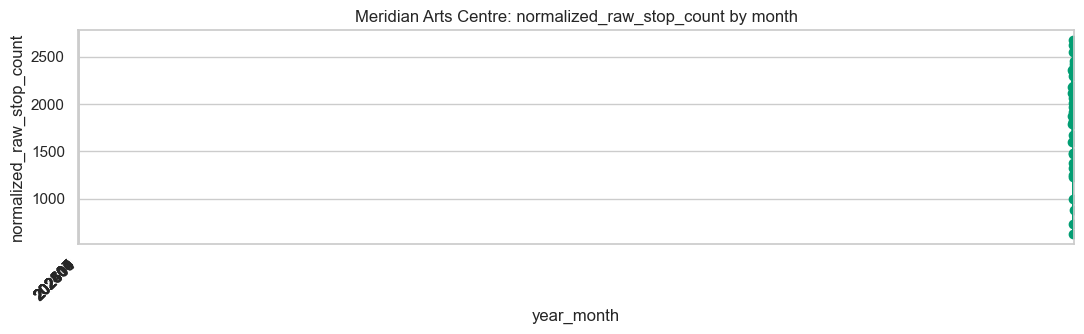

Range: 620 to 2,678 -- seasonal (higher Nov-Feb), not a single-month spike.

Meridian stops/visit ratio: 1.05 (citywide: 1.05) -- essentially typical, no unusual multi-stop merging.

Meridian volume-weighted repeat_device_prop across half-years: 17.2% (citywide: 14.3%) -- Meridian's repeat rate is somewhat HIGHER than typical, not a one-off draw.


In [21]:
# CELL — Meridian's monthly pattern, stops/visit ratio, and repeat-visit rate vs. citywide

mer_monthly = vs_all[vs_all["venue_id"] == meridian_id].set_index("year_month")["normalized_raw_stop_count"].sort_index()

fig, ax = plt.subplots(figsize=(11, 3.5))
mer_monthly.plot(ax=ax, marker="o", color=PALETTE[2])
ax.set_title("Meridian Arts Centre: normalized_raw_stop_count by month")
ax.set_ylabel("normalized_raw_stop_count")
ax.set_xticks(range(0, len(mer_monthly), 3))
ax.set_xticklabels(mer_monthly.index[::3], rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(f"Range: {mer_monthly.min():,.0f} to {mer_monthly.max():,.0f} -- "
      f"{'seasonal (higher Nov-Feb)' if mer_monthly.loc[[m for m in mer_monthly.index if str(m)[4:6] in ('11','12','01','02')]].mean() > mer_monthly.mean() else 'no obvious seasonality'}, not a single-month spike.")

mer_stops_visits = vs_all[vs_all["venue_id"] == meridian_id][["raw_stop_count", "visit_count"]].sum()
print(f"\nMeridian stops/visit ratio: {mer_stops_visits['raw_stop_count']/mer_stops_visits['visit_count']:.2f} "
      f"(citywide: {vs_all['raw_stop_count'].sum()/vs_all['visit_count'].sum():.2f}) -- essentially typical, no unusual multi-stop merging.")

repeat_visitors = pd.read_csv(VENUES_REPEAT_VISITORS_CSV)
rv_all = repeat_visitors[repeat_visitors["time_period"] == TIME_PERIOD]
mer_rv = rv_all[rv_all["venue_id"] == meridian_id]
mer_repeat_weighted = (mer_rv["repeat_device_prop"] * mer_rv["unique_devices"]).sum() / mer_rv["unique_devices"].sum()
city_repeat_weighted = (rv_all["repeat_device_prop"] * rv_all["unique_devices"]).sum() / rv_all["unique_devices"].sum()
print(f"\nMeridian volume-weighted repeat_device_prop across half-years: {mer_repeat_weighted:.1%} "
      f"(citywide: {city_repeat_weighted:.1%}) -- Meridian's repeat rate is somewhat HIGHER than typical, not a one-off draw.")

In [22]:
# CELL — Home-origin concentration: is Meridian unusually geographically concentrated?

with open(VENUE_METRICS_JSON) as f:
    venue_metrics_list = json.load(f)
hhi_by_venue = pd.Series({v["venue_name"]: v["home_origin_hhi"] for v in venue_metrics_list if v["home_origin_hhi"] is not None})

mer_hhi = hhi_by_venue["Meridian Arts Centre"]
mer_hhi_pctile = (hhi_by_venue < mer_hhi).mean()
print(f"Meridian Arts Centre home_origin_hhi: {mer_hhi:.3f}  (citywide median: {hhi_by_venue.median():.3f})")
print(f"Meridian is at the {mer_hhi_pctile:.0%} percentile of concentration across all 105 venues -- above-median, but NOT the most concentrated venue:")
print(hhi_by_venue.sort_values(ascending=False).head(5))

mer_dist = next(v["travel_distance_distribution"] for v in venue_metrics_list if v["venue_name"] == "Meridian Arts Centre")
print(f"\nMeridian's straight-line home-to-venue distance distribution: {mer_dist}")

mer_homes = venues_homes[(venues_homes["venue_id"] == meridian_id) & (venues_homes["time_period"] == TIME_PERIOD)]
top_cell = mer_homes.sort_values("normalized_raw_stop_count", ascending=False).iloc[0]
top_cell_share = top_cell["normalized_raw_stop_count"] / mer_homes["normalized_raw_stop_count"].sum()
print(f"\nMeridian's single largest home geohash6 cell ({top_cell['home_geohash6']}) accounts for "
      f"{top_cell_share:.1%} of its home-attributed activity, out of {mer_homes['home_geohash6'].nunique()} distinct home cells.")

Meridian Arts Centre home_origin_hhi: 0.283  (citywide median: 0.120)
Meridian is at the 84% percentile of concentration across all 105 venues -- above-median, but NOT the most concentrated venue:
Urban Arts                     0.895062
Humber Valley United Church    0.695972
Parkdale Hall                  0.625276
Mabelle Park                   0.582544
St. Lawrence Centre            0.464487
dtype: float64

Meridian's straight-line home-to-venue distance distribution: {'<1km': 52.0864, '1-3km': 17.9483, '3-10km': 16.7448, '10km+': 13.2205}

Meridian's single largest home geohash6 cell (dpz8bz) accounts for 44.1% of its home-attributed activity, out of 1087 distinct home cells.


In [23]:
# CELL — Decode the dominant home cell: how far is it really from the venue?

import pygeohash as pgh

cell_lat, cell_lon = pgh.decode(top_cell["home_geohash6"])

# venues-centroids.geojson properties don't carry lat/lon directly -- pull from the point geometry
venue_point = next(f["geometry"]["coordinates"] for f in _venues_raw["features"] if int(f["properties"]["id"]) == meridian_id)
venue_lon, venue_lat = venue_point

approx_km = np.sqrt((cell_lat - venue_lat)**2 + (cell_lon - venue_lon)**2) * 111  # rough deg->km, fine at this scale
print(f"Dominant home cell center: ({cell_lat:.4f}, {cell_lon:.4f})")
print(f"Venue location:            ({venue_lat:.4f}, {venue_lon:.4f})")
print(f"Approx. straight-line distance: {approx_km:.2f} km -- this geohash6 cell IS the block the venue itself sits in.")

Dominant home cell center: (43.7668, -79.4147)
Venue location:            (43.7661, -79.4144)
Approx. straight-line distance: 0.09 km -- this geohash6 cell IS the block the venue itself sits in.


**Assessment: Meridian's dominance is genuine activity, not a data-quality artifact, but its
home-origin concentration is ambiguous and worth flagging rather than over-interpreting.**
It has a normal stops/visit ratio, a seasonal (not spiky) monthly pattern, a higher-than-
average repeat-visit rate, and no footprint overlap with another venue -- nothing here
looks like a measurement error. But its single largest "home" cell is essentially the same
~600m block the venue itself occupies, in the dense Yonge-Sheppard mixed-use corridor (a
major subway interchange and shopping centre sit in the same cell). We **cannot rule out**
that some devices tagged "home" in that cell are proximity artifacts -- nearby staff,
office workers, transit riders, or mall visitors whose recurring-area detection places
them close to the venue rather than genuinely offsite residents who travel in -- alongside
what may well be real, heavy demand from the immediate neighbourhood. We treat this as an
open question, not a resolved one, in the Willowdale case study (Section 5).

### 2.4 Sensitivity: full sample vs. excluding Meridian Arts Centre

Because Meridian is so large and so locally concentrated, we check every citywide
outside-ward figure both ways.

In [24]:
# CELL — Full-sample vs. excluding-Meridian sensitivity on the citywide and per-ward outside-ward shares

def outside_ward_share(df):
    within = df.loc[df["is_home_ward"], VALUE_COL].sum()
    outside = df.loc[~df["is_home_ward"], VALUE_COL].sum()
    return outside / (within + outside)

full_outside = outside_ward_share(ward_to_venue_activity)
excl = ward_to_venue_activity[ward_to_venue_activity["venue_id"] != meridian_id]
excl_outside = outside_ward_share(excl)

print(f"Citywide outside-own-ward share, full sample:          {full_outside:.1%}")
print(f"Citywide outside-own-ward share, excluding Meridian:    {excl_outside:.1%}")

n_majority_outside_full = (ward_to_ward_summary["pct_outside_ward"] > 0.5).sum()
print(f"\nWards where >50% of recorded activity is outside the ward (full sample): {n_majority_outside_full} of 25")

per_ward_excl = excl.groupby("origin_ward").apply(outside_ward_share, include_groups=False)
n_majority_outside_excl = (per_ward_excl > 0.5).sum()
print(f"Same, excluding Meridian: {n_majority_outside_excl} of 25")

print("\nThese numbers reproduce the initial figures reported for this study "
      f"(~52.0% full-sample outside-ward, 20/25 wards majority-outside, ~60.8% excluding Meridian).")

Citywide outside-own-ward share, full sample:          52.0%
Citywide outside-own-ward share, excluding Meridian:    60.8%

Wards where >50% of recorded activity is outside the ward (full sample): 20 of 25
Same, excluding Meridian: 19 of 25

These numbers reproduce the initial figures reported for this study (~52.0% full-sample outside-ward, 20/25 wards majority-outside, ~60.8% excluding Meridian).


Both headline sensitivity numbers reproduce closely (52.0% -> 60.8% citywide outside-ward
share when Meridian is excluded). The count of majority-outside wards moves only slightly
(20 -> 19 of 25) and in the opposite direction from a naive guess -- removing Meridian
doesn't simply push every ward further "outside," because Meridian itself draws some of
its audience from other wards too; which wards sit just above/below the 50% line shifts at
the margin. **We treat 52% vs. 61% as a real range depending on how one venue is handled,
not a single precise citywide number**, and report both wherever this statistic recurs.

---

## Section 3 — A compact ward comparison table

One in-memory table, 25 rows, with origin-side and destination-side activity measures kept
separate, the five custom cultural-workforce measures kept separate, and a small set of
general census fields for later use. We build it in labelled pieces so each column's source
and meaning stays traceable.

In [25]:
# CELL — Piece 1: venue provision per ward (destination side, this study's inventory only)

venues_per_ward = venue_meta.merge(ward_to_venue_summary[["venue_id", "dest_ward"]], on="venue_id").groupby("dest_ward").size()
venues_per_ward = venues_per_ward.reindex(pop_general["ward_name"], fill_value=0).rename("n_venues_in_ward")

ward_comparison = pop_general.rename(columns={"pop_2021_general": "population"}).copy()
ward_comparison = ward_comparison.merge(venues_per_ward, left_on="ward_name", right_index=True)
ward_comparison["venues_per_100k"] = ward_comparison["n_venues_in_ward"] / ward_comparison["population"] * 100_000

print("'Included venues per 100,000 residents' describes THIS STUDY's 105-venue inventory, "
      "not all cultural infrastructure or venue capacity in the ward.")
ward_comparison.sort_values("venues_per_100k", ascending=False).head(5)

'Included venues per 100,000 residents' describes THIS STUDY's 105-venue inventory, not all cultural infrastructure or venue capacity in the ward.


,ward_code,ward_name,population,n_venues_in_ward,venues_per_100k
1656,10,Spadina-Fort York,136213.0,23,16.885319
1840,11,University-Rosedale,106216.0,16,15.063644
2208,13,Toronto Centre,119901.0,12,10.008257
1472,09,Davenport,105946.0,9,8.494894
552,04,Parkdale-High Park,106750.0,5,4.683841


In [26]:
# CELL — Piece 2: origin-side measures -- activity originating in each ward, and its
# leading destination ward / venue

origin_side = ward_to_ward_summary.rename(columns={
    "normalized_raw_stop_count_within_ward": "origin_within_ward",
    "normalized_raw_stop_count_outside_ward": "origin_outside_ward",
})
origin_side["origin_total"] = origin_side["origin_within_ward"] + origin_side["origin_outside_ward"]

# leading destination ward for each origin, EXCLUDING itself (the "where else do they go" question)
outside_flows = ward_to_ward_activity[~ward_to_ward_activity["same_ward"]]
top_dest_ward = outside_flows.sort_values(VALUE_COL, ascending=False).groupby("origin_ward").first().reset_index()
top_dest_ward = top_dest_ward[["origin_ward", "dest_ward", VALUE_COL]].rename(
    columns={"dest_ward": "top_outside_dest_ward", VALUE_COL: "top_outside_dest_ward_activity"})

# leading destination VENUE for each origin ward's residents (can be inside or outside the ward)
top_dest_venue = ward_to_venue_activity.sort_values(VALUE_COL, ascending=False).groupby("origin_ward").first().reset_index()
top_dest_venue = top_dest_venue[["origin_ward", "venue_name", VALUE_COL]].rename(
    columns={"venue_name": "top_dest_venue", VALUE_COL: "top_dest_venue_activity"})

origin_side = origin_side.merge(top_dest_ward, on="origin_ward").merge(top_dest_venue, on="origin_ward")
ward_comparison = ward_comparison.merge(origin_side, left_on="ward_name", right_on="origin_ward").drop(columns=["origin_ward"])
ward_comparison[["ward_name", "origin_total", "pct_inside_ward", "pct_outside_ward", "top_outside_dest_ward", "top_dest_venue"]].head(5)

,ward_name,origin_total,pct_inside_ward,pct_outside_ward,top_outside_dest_ward,top_dest_venue
0,Etobicoke North,1639.197820,0.437667,0.562333,Willowdale,Albion Library
1,Etobicoke Centre,1535.565322,0.373222,0.626778,University-Rosedale,Humber Valley United Church
2,Etobicoke-Lakeshore,1513.261320,0.113056,0.886944,Spadina-Fort York,Meridian Arts Centre
3,Parkdale-High Park,4132.671970,0.224180,0.775820,Spadina-Fort York,Parkdale Hall
4,York South-Weston,2943.600356,0.004026,0.995974,University-Rosedale,Royal Ontario Museum


In [27]:
# CELL — Piece 3: destination-side measures -- activity received by venues IN each ward,
# how much of it comes from outside, its leading origin ward, and venue concentration

dest_totals = ward_to_ward_activity.groupby("dest_ward")[VALUE_COL].sum().rename("dest_total")
dest_from_outside = ward_to_ward_activity[~ward_to_ward_activity["same_ward"]].groupby("dest_ward")[VALUE_COL].sum().rename("dest_from_outside")
dest_side = pd.concat([dest_totals, dest_from_outside], axis=1).fillna(0.0).reset_index()  # -> explicit "dest_ward" column
dest_side["dest_pct_from_outside"] = np.where(dest_side["dest_total"] > 0, dest_side["dest_from_outside"] / dest_side["dest_total"], np.nan)

# leading origin ward for each destination, excluding itself
top_origin_ward = outside_flows.sort_values(VALUE_COL, ascending=False).groupby("dest_ward").first().reset_index()
top_origin_ward = top_origin_ward[["dest_ward", "origin_ward", VALUE_COL]].rename(
    columns={"origin_ward": "top_outside_origin_ward", VALUE_COL: "top_outside_origin_ward_activity"})
dest_side = dest_side.merge(top_origin_ward, on="dest_ward", how="left")

# concentration in the largest / top-3 venues located in each destination ward -- dest_ward
# is already each venue's own (fixed) ward in ward_to_venue_activity, so summing VALUE_COL
# over all 25 origin rows per (dest_ward, venue_id) gives that venue's total received activity
venue_dest_totals = ward_to_venue_activity.groupby(["dest_ward", "venue_id"])[VALUE_COL].sum().reset_index()

def top_n_share(g, n):
    total = g[VALUE_COL].sum()
    if total <= 0:
        return np.nan
    return g.nlargest(n, VALUE_COL)[VALUE_COL].sum() / total

conc = venue_dest_totals.groupby("dest_ward").apply(lambda g: pd.Series({
    "venue_conc_top1": top_n_share(g, 1),
    "venue_conc_top3": top_n_share(g, 3),
}), include_groups=False).reset_index()

dest_side = dest_side.merge(conc, on="dest_ward", how="left")
ward_comparison = ward_comparison.merge(dest_side, left_on="ward_name", right_on="dest_ward").drop(columns=["dest_ward"])
ward_comparison[["ward_name", "dest_total", "dest_pct_from_outside", "top_outside_origin_ward", "venue_conc_top1", "venue_conc_top3"]].sort_values("venue_conc_top1", ascending=False).head(5)

,ward_name,dest_total,dest_pct_from_outside,top_outside_origin_ward,venue_conc_top1,venue_conc_top3
0,Etobicoke North,1164.177354,0.383751,Humber River-Black Creek,1.0,1.0
4,York South-Weston,12.712093,0.067785,Parkdale-High Park,1.0,1.0
7,Eglinton-Lawrence,1229.862014,0.455518,York South-Weston,1.0,1.0
16,Don Valley North,2077.008618,0.351925,Don Valley East,1.0,1.0
24,Scarborough-Rouge Park,1486.371230,0.260045,Scarborough North,1.0,1.0


In [28]:
# CELL — Piece 4: merge in the 5 custom cultural-workforce measures (kept separate) and a
# small set of general census fields (with meaningful denominators computed here, not
# borrowed from a different population base)

noc_naics_cols = ["ward_code"] + [f"{m}_count" for m in NOC_NAICS_MEASURES] + [f"{m}_pct" for m in NOC_NAICS_MEASURES]
ward_comparison = ward_comparison.merge(ward_noc_naics[noc_naics_cols], on="ward_code")

census_subset = ward_census_wide.copy()
census_subset["renter_share"] = census_subset["housing_tenure_renter"] / census_subset["housing_tenure_total"]
census_subset["visible_minority_share"] = census_subset["visible_minority_yes"] / census_subset["visible_minority_total"]
census_subset["not_citizen_share"] = census_subset["citizen_not_canadian"] / census_subset["citizen_total"]
census_subset["bachelor_or_higher_share"] = census_subset["education_bachelor_higher"] / census_subset["education_total"]
census_subset["transit_commute_share"] = census_subset["commute_mode_transit"] / census_subset["commute_mode_total"]
census_subset["arts_occupation_share"] = census_subset["labour_occupation_5_arts_culture"] / census_subset["labour_occupation_total"]
census_subset["arts_industry_share"] = census_subset["labour_industry_71_arts"] / census_subset["labour_industry_total"]

census_cols = ["ward_code", "income_total_median", "age_median", "pop_density",
               "renter_share", "visible_minority_share", "not_citizen_share",
               "bachelor_or_higher_share", "transit_commute_share",
               "arts_occupation_share", "arts_industry_share",
               "labour_occupation_5_arts_culture", "labour_industry_71_arts"]
ward_comparison = ward_comparison.merge(census_subset[census_cols], on="ward_code")

print(f"ward_comparison: {ward_comparison.shape}")
assert len(ward_comparison) == 25 and ward_comparison["ward_code"].is_unique
ward_comparison.head(3)

ward_comparison: (25, 43)


,ward_code,ward_name,population,n_venues_in_ward,venues_per_100k,origin_within_ward,origin_outside_ward,pct_inside_ward,pct_outside_ward,origin_total,top_outside_dest_ward,top_outside_dest_ward_activity,top_dest_venue,top_dest_venue_activity,dest_total,dest_from_outside,dest_pct_from_outside,top_outside_origin_ward,top_outside_origin_ward_activity,venue_conc_top1,venue_conc_top3,labour_creatives_count,labour_cultural_workers_count,labour_cultural_industries_count,labour_independent_artists_count,labour_arts_major_count,labour_creatives_pct,labour_cultural_workers_pct,labour_cultural_industries_pct,labour_independent_artists_pct,labour_arts_major_pct,income_total_median,age_median,pop_density,renter_share,visible_minority_share,not_citizen_share,bachelor_or_higher_share,transit_commute_share,arts_occupation_share,arts_industry_share,labour_occupation_5_arts_culture,labour_industry_71_arts
0,01,Etobicoke North,116003.0,1,0.862047,717.423405,921.774416,0.437667,0.562333,1639.197820,Willowdale,328.420952,Albion Library,717.423405,1164.177354,446.753950,0.383751,Humber River-Black Creek,262.563510,1.000000,1.00000,344.579891,700.252677,825.730870,124.498434,1761.983531,0.4,0.7,0.8,0.1,1.8,32400.0,38.0,2428.3,0.454760,0.782966,0.204448,0.228938,0.224755,0.015804,0.014319,905.0,820.0
1,02,Etobicoke Centre,118483.0,3,2.532009,573.106645,962.458677,0.373222,0.626778,1535.565322,University-Rosedale,251.798587,Humber Valley United Church,522.521262,707.993613,134.886969,0.190520,Don Valley North,36.481556,0.790043,1.00000,975.371948,1832.418101,1533.500842,337.752790,3960.920034,1.0,1.8,1.5,0.3,4.0,44400.0,45.6,3198.3,0.325946,0.317435,0.093213,0.375776,0.153891,0.036475,0.018278,2235.0,1120.0
2,03,Etobicoke-Lakeshore,141751.0,4,2.821850,171.082918,1342.178401,0.113056,0.886944,1513.261320,Spadina-Fort York,376.934327,Meridian Arts Centre,199.983002,238.623659,67.540741,0.283043,Etobicoke Centre,23.939768,0.707750,0.93677,2106.414632,3616.235401,2841.024347,621.277921,5887.014148,2.0,3.4,2.7,0.6,5.5,47600.0,40.8,3575.4,0.430957,0.347890,0.134291,0.446032,0.216757,0.053406,0.019289,4430.0,1600.0


---

## Section 4 — Story angles

### A. Venues serve residents beyond their own ward

We already computed the headline numbers in Section 2.4: **52.0% of normalized ward-mapped
activity is outside the resident's own ward citywide (60.8% excluding Meridian Arts
Centre)**, and **20 of 25 wards (19 excluding Meridian)** have a majority-outside share.
Here we show the distribution behind that citywide number, and where residents' activity
actually goes.

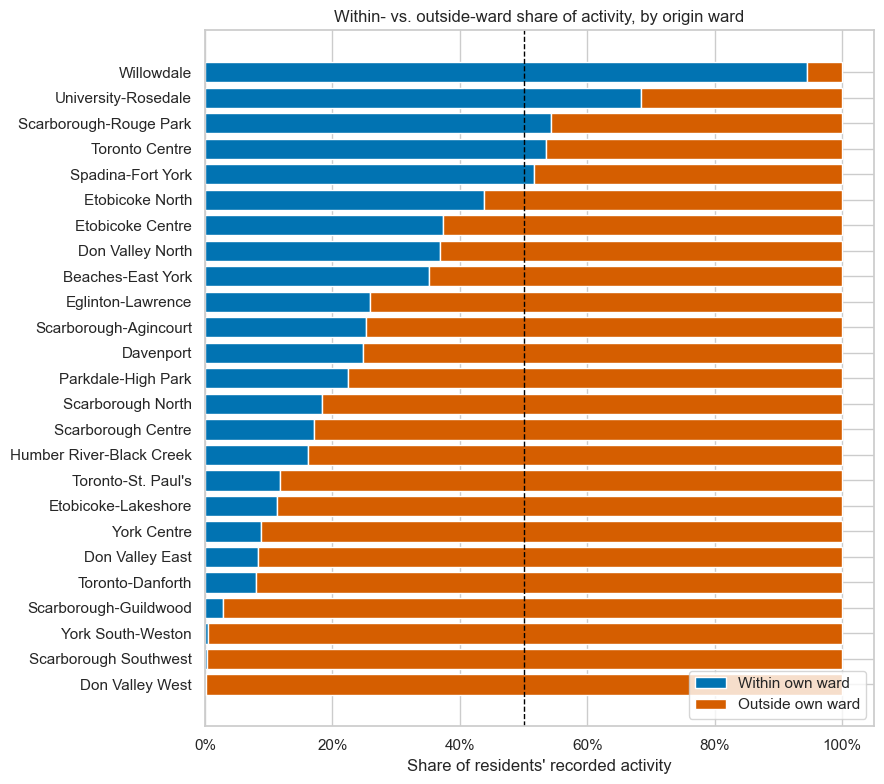

This is the DISTRIBUTION ACROSS WARDS view: each bar has equal weight regardless of how much
total activity that ward represents. The 52.0% citywide figure is ACTIVITY-WEIGHTED instead --
it answers 'what share of all recorded activity crosses a ward line', which large-activity wards
(like Willowdale, dominated by within-ward Meridian activity) influence more than small ones.
Both are legitimate; they answer different questions and can point in different directions.


In [29]:
# CELL — Sorted within/outside-ward stacked bar, all 25 wards

plot_df = ward_to_ward_summary.sort_values("pct_inside_ward", ascending=True)
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(plot_df["origin_ward"], plot_df["pct_inside_ward"], color=PALETTE[0], label="Within own ward")
ax.barh(plot_df["origin_ward"], plot_df["pct_outside_ward"], left=plot_df["pct_inside_ward"], color=PALETTE[3], label="Outside own ward")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Share of residents' recorded activity")
ax.set_title("Within- vs. outside-ward share of activity, by origin ward")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

print("This is the DISTRIBUTION ACROSS WARDS view: each bar has equal weight regardless of how much")
print("total activity that ward represents. The 52.0% citywide figure is ACTIVITY-WEIGHTED instead --")
print("it answers 'what share of all recorded activity crosses a ward line', which large-activity wards")
print("(like Willowdale, dominated by within-ward Meridian activity) influence more than small ones.")
print("Both are legitimate; they answer different questions and can point in different directions.")

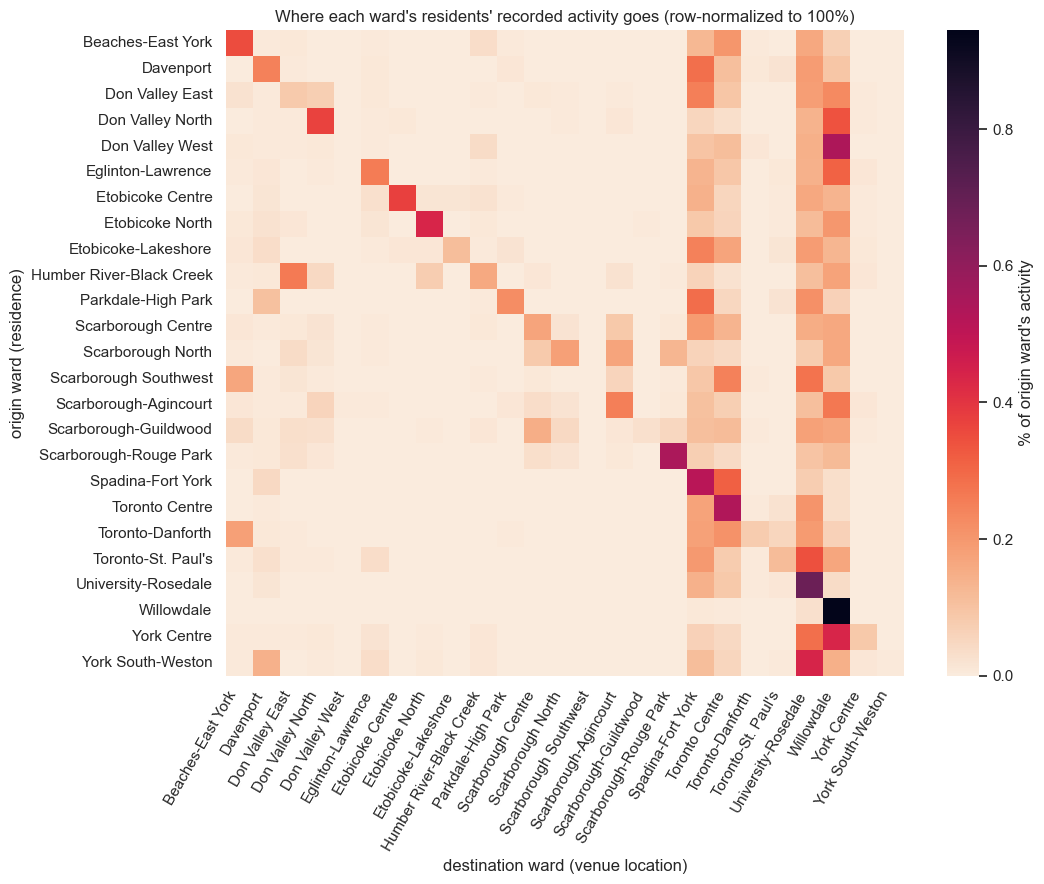

Reading the diagonal: most rows are brightest on the diagonal (residents' own ward is usually
their single biggest destination), but several rows are nearly as bright in ONE other column --
i.e. a ward that isn't the resident's own, but pulls a large minority share consistently.


In [30]:
# CELL — Origin-normalized ward-to-ward heatmap: for each origin ward's residents (rows),
# what share of THEIR activity lands in each destination ward (columns)? Row-normalized,
# so every row sums to 100% -- this shows destination PATTERN independent of ward size.

pct_of_origin_matrix = ward_to_ward_activity.pivot(index="origin_ward", columns="dest_ward", values="pct_of_origin")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(pct_of_origin_matrix, cmap="rocket_r", cbar_kws={"label": "% of origin ward's activity"}, ax=ax)
ax.set_title("Where each ward's residents' recorded activity goes (row-normalized to 100%)")
ax.set_xlabel("destination ward (venue location)")
ax.set_ylabel("origin ward (residence)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

print("Reading the diagonal: most rows are brightest on the diagonal (residents' own ward is usually")
print("their single biggest destination), but several rows are nearly as bright in ONE other column --")
print("i.e. a ward that isn't the resident's own, but pulls a large minority share consistently.")

In [31]:
# CELL — Compact view: leading outside-ward destination for every origin ward

leading_dest = ward_comparison[["ward_name", "top_outside_dest_ward", "top_dest_venue"]].sort_values("ward_name")
leading_dest.columns = ["Origin ward", "Leading OUTSIDE destination ward", "Single leading destination venue"]
leading_dest

,Origin ward,Leading OUTSIDE destination ward,Single leading destination venue
18,Beaches-East York,Toronto Centre,Children's Peace Theatre
8,Davenport,Spadina-Fort York,Toronto Reference Library
15,Don Valley East,Spadina-Fort York,Meridian Arts Centre
16,Don Valley North,Willowdale,Fairview Library
14,Don Valley West,Willowdale,Meridian Arts Centre
7,Eglinton-Lawrence,Willowdale,Meridian Arts Centre
1,Etobicoke Centre,University-Rosedale,Humber Valley United Church
0,Etobicoke North,Willowdale,Albion Library
2,Etobicoke-Lakeshore,Spadina-Fort York,Meridian Arts Centre
6,Humber River-Black Creek,Don Valley East,The Aga Khan Museum


**Finding:** cross-ward activity is large and widespread -- most wards send a majority of
their recorded activity to venues elsewhere, and this is true across the whole city, not
concentrated in one corner of it. **Interpretation a councillor could draw:** a venue's
value to the city is not confined to the ward it happens to sit in, so ward-by-ward
per-capita venue counts alone understate how many residents a given piece of cultural
infrastructure actually reaches. **What this does NOT show:** which wards' TAC funding is
"returned" via this cross-ward reach -- that would require linking specific venues'
funding amounts to this flow, and we only have funding as a yes/no flag (Section 1.3), not
a dollar amount, so we do not make a funding-equity claim from this alone.

### B. Local infrastructure and regional connections

Do wards with fewer included venues rely more on destinations elsewhere? A high
outside-ward share could reflect limited local options, an attractive regional draw,
ward-boundary geometry, or several of these together -- it is not on its own evidence of
unmet demand or poor access. We look for exceptions and for suburb-to-suburb connections
specifically, rather than assuming every cross-ward flow points downtown.

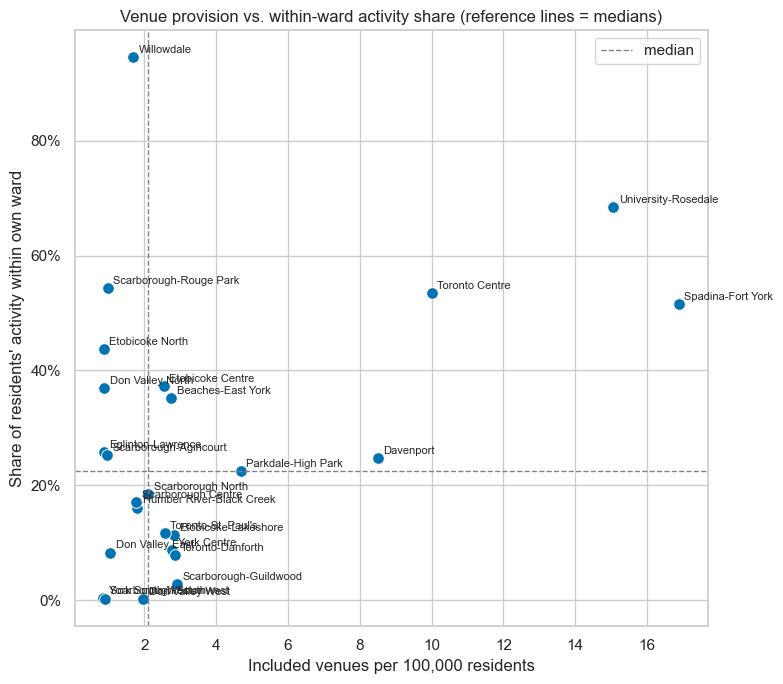

In [32]:
# CELL — Labelled scatterplot: venue provision vs. within-ward activity share

fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(data=ward_comparison, x="venues_per_100k", y="pct_inside_ward", s=70, ax=ax, color=PALETTE[0])
for _, row in ward_comparison.iterrows():
    ax.annotate(row["ward_name"], (row["venues_per_100k"], row["pct_inside_ward"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(ward_comparison["pct_inside_ward"].median(), color="gray", linestyle="--", linewidth=1, label="median")
ax.axvline(ward_comparison["venues_per_100k"].median(), color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Included venues per 100,000 residents")
ax.set_ylabel("Share of residents' activity within own ward")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Venue provision vs. within-ward activity share (reference lines = medians)")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# CELL — Quantify the relationship, and flag exceptions (high provision + low within-ward
# share, or low provision + high within-ward share -- these are the interesting cases)

corr = ward_comparison[["venues_per_100k", "pct_inside_ward"]].corr().iloc[0, 1]
print(f"Correlation (venues per 100k vs. within-ward share), n=25 wards: {corr:.2f}")

med_venues = ward_comparison["venues_per_100k"].median()
med_inside = ward_comparison["pct_inside_ward"].median()

low_prov_high_local = ward_comparison[(ward_comparison["venues_per_100k"] <= med_venues) & (ward_comparison["pct_inside_ward"] >= med_inside)]
high_prov_low_local = ward_comparison[(ward_comparison["venues_per_100k"] >= med_venues) & (ward_comparison["pct_inside_ward"] <= med_inside)]

print(f"\nLow provision, but still high within-ward share (exception to 'few venues -> outsourced activity'):")
print(low_prov_high_local[["ward_name", "n_venues_in_ward", "venues_per_100k", "pct_inside_ward"]].to_string(index=False))

print(f"\nHigh provision, but still low within-ward share (exception the other way -- venues present, residents still leave):")
print(high_prov_low_local[["ward_name", "n_venues_in_ward", "venues_per_100k", "pct_inside_ward"]].to_string(index=False))

Correlation (venues per 100k vs. within-ward share), n=25 wards: 0.42

Low provision, but still high within-ward share (exception to 'few venues -> outsourced activity'):
             ward_name  n_venues_in_ward  venues_per_100k  pct_inside_ward
       Etobicoke North                 1         0.862047         0.437667
     Eglinton-Lawrence                 1         0.863319         0.258561
      Don Valley North                 1         0.879794         0.369076
            Willowdale                 2         1.691790         0.944701
 Scarborough-Agincourt                 1         0.957643         0.253263
Scarborough-Rouge Park                 1         0.977957         0.543521

High provision, but still low within-ward share (exception the other way -- venues present, residents still leave):
            ward_name  n_venues_in_ward  venues_per_100k  pct_inside_ward
  Etobicoke-Lakeshore                 4         2.821850         0.113056
   Parkdale-High Park                 5

In [34]:
# CELL — Are cross-ward flows mostly downtown-bound, or do suburban wards connect to each other?
#
# We tag wards as "downtown core" using the old City of Toronto wards that sit inside the
# pre-amalgamation core (Davenport, Spadina-Fort York, University-Rosedale, Toronto Centre,
# Toronto-Danforth, Toronto-St. Paul's, Beaches-East York) vs. everything else ("suburban":
# the former Etobicoke, York, North York, Scarborough municipalities) -- a standard,
# well-known geographic grouping, not a data-derived category.

DOWNTOWN_CORE_WARDS = {
    "Davenport", "Spadina-Fort York", "University-Rosedale", "Toronto Centre",
    "Toronto-Danforth", "Toronto-St. Paul's", "Beaches-East York",
}

flows = outside_flows.copy()
flows["origin_is_suburban"] = ~flows["origin_ward"].isin(DOWNTOWN_CORE_WARDS)
flows["dest_is_downtown"] = flows["dest_ward"].isin(DOWNTOWN_CORE_WARDS)

suburban_origin_flows = flows[flows["origin_is_suburban"]]
suburb_to_suburb = suburban_origin_flows.loc[~suburban_origin_flows["dest_is_downtown"], VALUE_COL].sum()
suburb_to_downtown = suburban_origin_flows.loc[suburban_origin_flows["dest_is_downtown"], VALUE_COL].sum()

print(f"Of suburban wards' OUTSIDE-ward activity:")
print(f"  -> to another suburban ward: {suburb_to_suburb:,.0f}  ({suburb_to_suburb/(suburb_to_suburb+suburb_to_downtown):.1%})")
print(f"  -> to a downtown-core ward:  {suburb_to_downtown:,.0f}  ({suburb_to_downtown/(suburb_to_suburb+suburb_to_downtown):.1%})")
print("\nThis directly tests the 'not a downtown-only story' framing from the task brief.")

Of suburban wards' OUTSIDE-ward activity:
  -> to another suburban ward: 14,883  (43.1%)
  -> to a downtown-core ward:  19,620  (56.9%)

This directly tests the 'not a downtown-only story' framing from the task brief.


In [35]:
# CELL — Compact table of contrasting wards: lowest vs. highest venue provision

contrast_cols = ["ward_name", "n_venues_in_ward", "venues_per_100k", "pct_inside_ward", "top_outside_dest_ward", "population"]
print("5 wards with the FEWEST included venues per 100k:")
display(ward_comparison.sort_values("venues_per_100k").head(5)[contrast_cols])
print("\n5 wards with the MOST included venues per 100k:")
display(ward_comparison.sort_values("venues_per_100k", ascending=False).head(5)[contrast_cols])

5 wards with the FEWEST included venues per 100k:


,ward_name,n_venues_in_ward,venues_per_100k,pct_inside_ward,top_outside_dest_ward,population
4,York South-Weston,1,0.856480,0.004026,University-Rosedale,116757.0
0,Etobicoke North,1,0.862047,0.437667,Willowdale,116003.0
7,Eglinton-Lawrence,1,0.863319,0.258561,Willowdale,115832.0
16,Don Valley North,1,0.879794,0.369076,Willowdale,113663.0
19,Scarborough Southwest,1,0.892905,0.002887,University-Rosedale,111994.0



5 wards with the MOST included venues per 100k:


,ward_name,n_venues_in_ward,venues_per_100k,pct_inside_ward,top_outside_dest_ward,population
9,Spadina-Fort York,23,16.885319,0.516089,Toronto Centre,136213.0
10,University-Rosedale,16,15.063644,0.684440,Spadina-Fort York,106216.0
12,Toronto Centre,12,10.008257,0.534949,University-Rosedale,119901.0
8,Davenport,9,8.494894,0.248029,Spadina-Fort York,105946.0
3,Parkdale-High Park,5,4.683841,0.224180,Spadina-Fort York,106750.0


**Finding:** venue provision and within-ward activity share are only weakly related across
the 25 wards (see the printed correlation above), and there are real exceptions in both
directions -- some low-provision wards still show high within-ward activity, and some
higher-provision wards still send most activity elsewhere. Cross-ward flows are not purely
a "suburbs feed downtown" pattern; a substantial share of suburban wards' outside-ward
activity lands in other suburban wards. **Interpretation:** a low within-ward share is
consistent with several different mechanisms (limited local supply, a strong regional
draw nearby, or simply a ward boundary that cuts through a natural catchment area) --
distinguishing between them needs the venue-by-venue detail in the case studies (Section 5),
not this table alone. **What this does not show:** unmet demand -- we have no data on
residents who wanted to attend something locally and could not.

### C. Artists and cultural workers already live across Toronto

Using `toronto-wards-noc-naics.csv` as the primary source (Section 1.2), we examine the
five custom measures **separately** -- never summed -- alongside both their counts (scale)
and published percentages (concentration under that measure's own age-15+ denominator).

**Concept mapping -- only as far as the data supports it:** per Section 1.2, we cannot
verify the underlying NOC/NAICS/CIP codes, so we map concepts loosely to StatCan's own
plain-language category labels, not to a narrower interpretation:

| Concept | Closest available measure | Caveat |
|---|---|---|
| Artists specifically | `labour_independent_artists` (NAICS: independent artists & arts orgs) | An *industry* measure (where people work), not an occupation-based "is an artist" test |
| Broader cultural workforce | `labour_cultural_workers` (NOC) | StatCan's own "cultural workers" occupation label, broader than `labour_creatives` |
| Employed in cultural industries | `labour_cultural_industries` (NAICS) | Industry-based; may include non-creative roles (admin, ops) within cultural organizations |
| Arts-related education | `labour_arts_major` (CIP) | Field of study, not current occupation -- someone can hold this credential and work elsewhere |
| Broader creative workforce | `labour_creatives` (NOC) | StatCan's broadest occupation-based label of the two NOC slices |

These mappings are our best reading of StatCan's plain-language labels, not a verified
code-level classification -- treat "artists specifically" especially loosely.

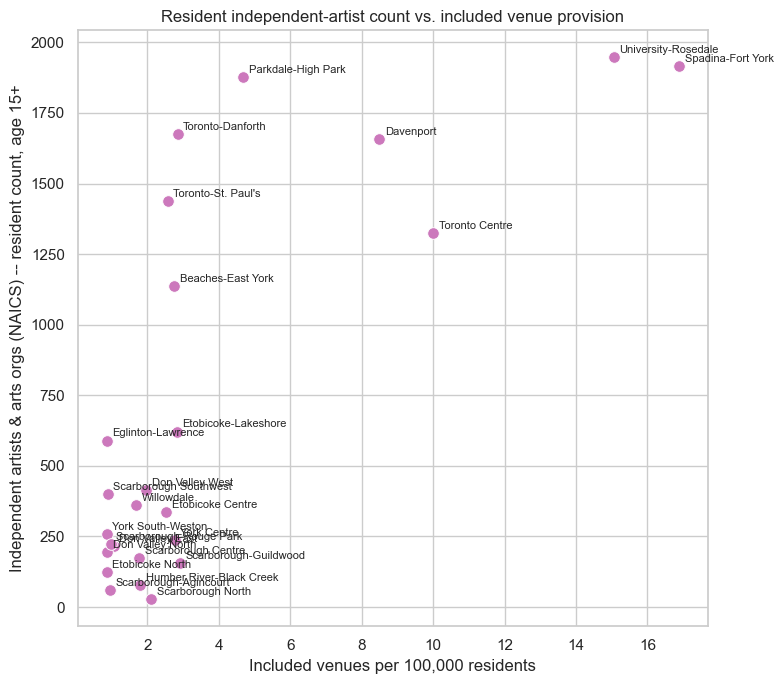

Correlation, RAW COUNT vs. venues per 100k:        0.75  (confounded by ward population size)
Correlation, POPULATION-ADJUSTED PCT vs. same:     0.67  (fairer per-capita comparison)

The count-based correlation is high mainly because bigger wards have more of everything;
the pct-based correlation is the more honest test of whether artist CONCENTRATION tracks venue density.


In [36]:
# CELL — Labelled scatterplot: independent artists (count) vs. included venue provision

fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(data=ward_comparison, x="venues_per_100k", y="labour_independent_artists_count", s=70, ax=ax, color=PALETTE[4])
for _, row in ward_comparison.iterrows():
    ax.annotate(row["ward_name"], (row["venues_per_100k"], row["labour_independent_artists_count"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Included venues per 100,000 residents")
ax.set_ylabel("Independent artists & arts orgs (NAICS) -- resident count, age 15+")
ax.set_title("Resident independent-artist count vs. included venue provision")
plt.tight_layout()
plt.show()

corr_count = ward_comparison[["labour_independent_artists_count", "venues_per_100k"]].corr().iloc[0, 1]
# the count vs. a per-capita venue measure is a population-scale-confounded comparison
# (bigger wards mechanically have more of both) -- the fairer, population-adjusted test
# uses the measure's own PCT instead of its raw count on both sides
corr_pct = ward_comparison[["labour_independent_artists_pct", "venues_per_100k"]].corr().iloc[0, 1]
print(f"Correlation, RAW COUNT vs. venues per 100k:        {corr_count:.2f}  (confounded by ward population size)")
print(f"Correlation, POPULATION-ADJUSTED PCT vs. same:     {corr_pct:.2f}  (fairer per-capita comparison)")
print("\nThe count-based correlation is high mainly because bigger wards have more of everything;")
print("the pct-based correlation is the more honest test of whether artist CONCENTRATION tracks venue density.")

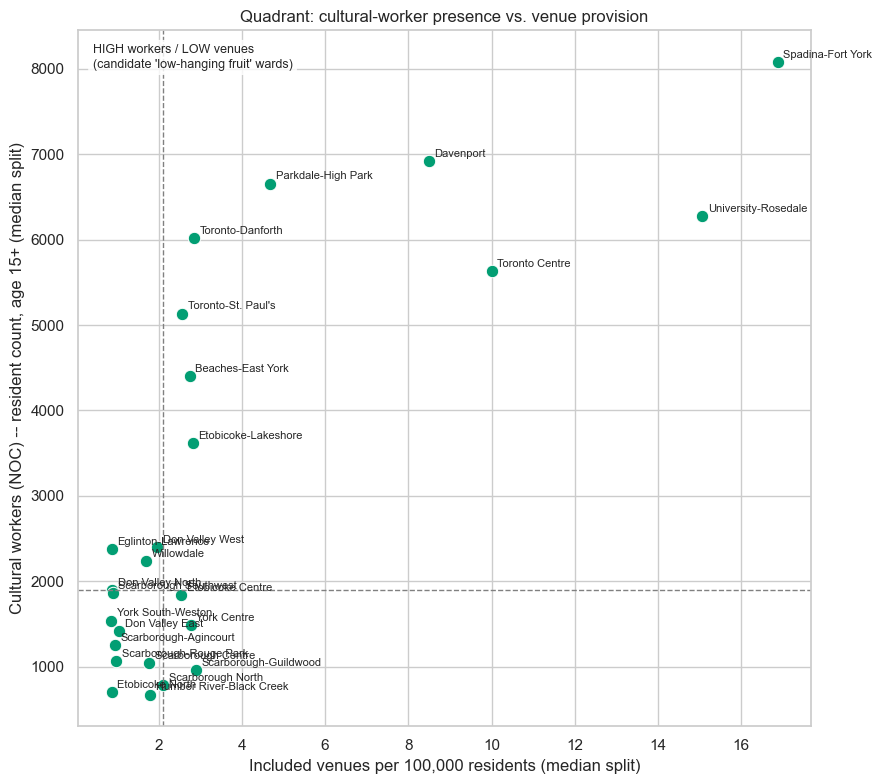

Wards in the HIGH cultural-worker / LOW venue-provision quadrant:
        ward_name  labour_cultural_workers_count  labour_cultural_workers_pct  n_venues_in_ward  venues_per_100k
  Don Valley West                    2397.864048                          2.9                 2         1.961573
Eglinton-Lawrence                    2373.959054                          2.5                 1         0.863319
       Willowdale                    2234.405527                          2.2                 2         1.691790
 Don Valley North                    1892.274946                          1.9                 1         0.879794


In [37]:
# CELL — Quadrant plot: cultural-worker presence (count) vs. venue provision, split at medians
# (transparent reference lines, not an arbitrary composite index)

med_workers = ward_comparison["labour_cultural_workers_count"].median()
med_venues100k = ward_comparison["venues_per_100k"].median()

fig, ax = plt.subplots(figsize=(9, 8))
sns.scatterplot(data=ward_comparison, x="venues_per_100k", y="labour_cultural_workers_count", s=80, ax=ax, color=PALETTE[2])
for _, row in ward_comparison.iterrows():
    ax.annotate(row["ward_name"], (row["venues_per_100k"], row["labour_cultural_workers_count"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(med_workers, color="gray", linestyle="--", linewidth=1)
ax.axvline(med_venues100k, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Included venues per 100,000 residents (median split)")
ax.set_ylabel("Cultural workers (NOC) -- resident count, age 15+ (median split)")
ax.set_title("Quadrant: cultural-worker presence vs. venue provision")
ax.text(0.02, 0.98, "HIGH workers / LOW venues\n(candidate 'low-hanging fruit' wards)", transform=ax.transAxes,
        va="top", ha="left", fontsize=9, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout()
plt.show()

quadrant_candidates = ward_comparison[
    (ward_comparison["labour_cultural_workers_count"] >= med_workers) & (ward_comparison["venues_per_100k"] <= med_venues100k)
].sort_values("labour_cultural_workers_count", ascending=False)
print("Wards in the HIGH cultural-worker / LOW venue-provision quadrant:")
print(quadrant_candidates[["ward_name", "labour_cultural_workers_count", "labour_cultural_workers_pct", "n_venues_in_ward", "venues_per_100k"]].to_string(index=False))

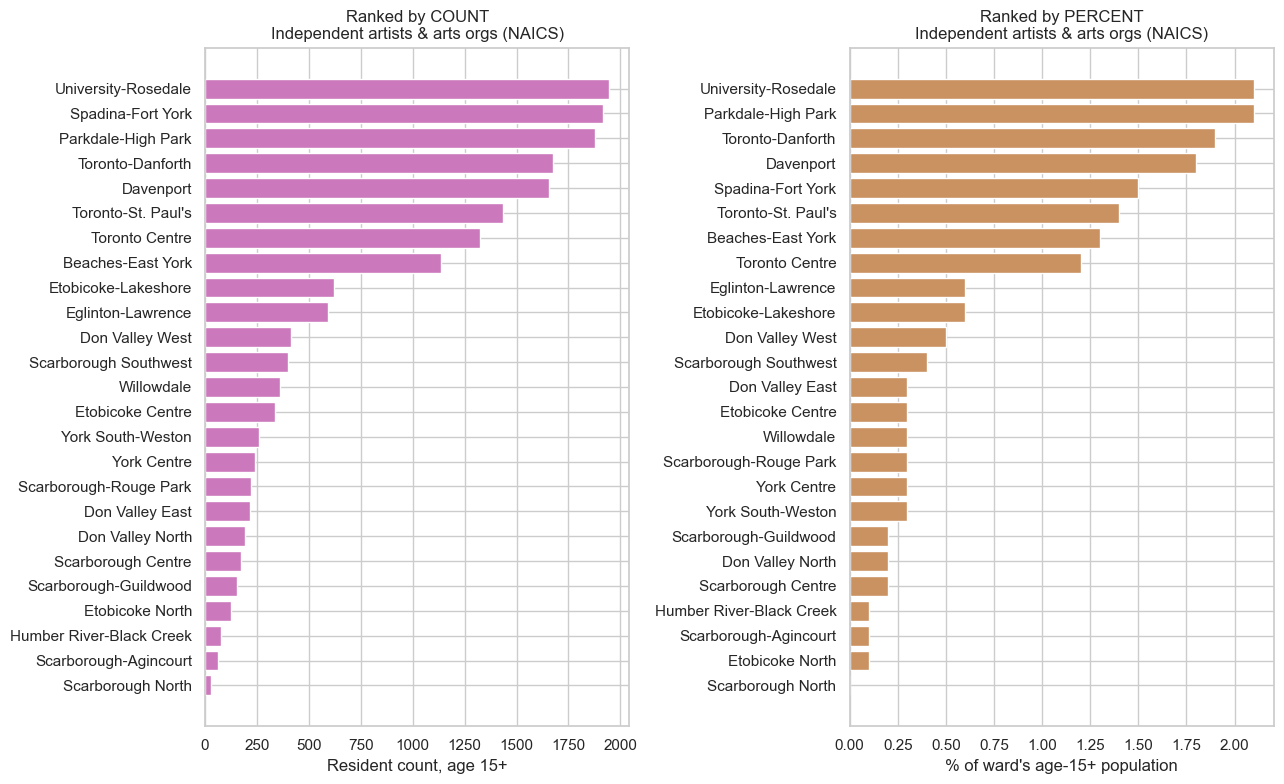

Top 5 by count: ['Davenport', 'Parkdale-High Park', 'Spadina-Fort York', 'Toronto-Danforth', 'University-Rosedale']
Top 5 by pct:   ['Davenport', 'Parkdale-High Park', 'Spadina-Fort York', 'Toronto-Danforth', 'University-Rosedale']
In one ranking's top 5 but not the other's: []


In [38]:
# CELL — Paired ranked plot: count vs. percent ranking can disagree -- a low % in a
# populous ward can still be a large # of people, and vice versa

measure = "labour_independent_artists"
fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=False)

by_count = ward_comparison.sort_values(f"{measure}_count", ascending=True)
axes[0].barh(by_count["ward_name"], by_count[f"{measure}_count"], color=PALETTE[4])
axes[0].set_title(f"Ranked by COUNT\n{NOC_NAICS_LABELS[measure]}")
axes[0].set_xlabel("Resident count, age 15+")

by_pct = ward_comparison.sort_values(f"{measure}_pct", ascending=True)
axes[1].barh(by_pct["ward_name"], by_pct[f"{measure}_pct"], color=PALETTE[5])
axes[1].set_title(f"Ranked by PERCENT\n{NOC_NAICS_LABELS[measure]}")
axes[1].set_xlabel("% of ward's age-15+ population")

plt.tight_layout()
plt.show()

top5_count = set(ward_comparison.nlargest(5, f"{measure}_count")["ward_name"])
top5_pct = set(ward_comparison.nlargest(5, f"{measure}_pct")["ward_name"])
print(f"Top 5 by count: {sorted(top5_count)}")
print(f"Top 5 by pct:   {sorted(top5_pct)}")
print(f"In one ranking's top 5 but not the other's: {sorted(top5_count ^ top5_pct)}")

In [39]:
# CELL — Sensitivity table: do the same wards lead across all 5 definitions (by count)?

top5_by_measure = {}
for m in tqdm(NOC_NAICS_MEASURES, desc="ranking wards per measure"):
    top5_by_measure[NOC_NAICS_LABELS[m]] = list(ward_comparison.nlargest(5, f"{m}_count")["ward_name"])

sensitivity_table = pd.DataFrame(top5_by_measure)
sensitivity_table.index = [f"#{i+1}" for i in range(5)]
print("Top-5 wards by resident COUNT, one column per custom definition:")
sensitivity_table

ranking wards per measure:   0%|          | 0/5 [00:00<?, ?it/s]

Top-5 wards by resident COUNT, one column per custom definition:


,Creatives (NOC),Cultural workers (NOC),Cultural industries (NAICS),Independent artists & arts orgs (NAICS),Arts-major education (CIP)
#1,Spadina-Fort York,Spadina-Fort York,Spadina-Fort York,University-Rosedale,Spadina-Fort York
#2,Davenport,Davenport,Parkdale-High Park,Spadina-Fort York,University-Rosedale
#3,Parkdale-High Park,Parkdale-High Park,Davenport,Parkdale-High Park,Parkdale-High Park
#4,University-Rosedale,University-Rosedale,Toronto-Danforth,Toronto-Danforth,Davenport
#5,Toronto-Danforth,Toronto-Danforth,University-Rosedale,Davenport,Toronto-St. Paul's


In [40]:
# CELL — Which wards recur across most/all 5 top-5 lists?

from collections import Counter
appearance_counts = Counter(w for wards in top5_by_measure.values() for w in wards)
recurring = pd.Series(appearance_counts).sort_values(ascending=False)
print("How many of the 5 top-5 lists each ward appears in:")
print(recurring.to_string())
print(f"\nWards appearing in all 5: {[w for w, c in appearance_counts.items() if c == 5]}")

How many of the 5 top-5 lists each ward appears in:
Spadina-Fort York      5
Davenport              5
Parkdale-High Park     5
University-Rosedale    5
Toronto-Danforth       4
Toronto-St. Paul's     1

Wards appearing in all 5: ['Spadina-Fort York', 'Davenport', 'Parkdale-High Park', 'University-Rosedale']


#### Custom measures vs. the broader standard census categories

`toronto-wards.csv` has two much broader standard StatCan fields that are sometimes used
as an "arts" proxy: `labour_occupation_5_arts_culture` (NOC major group 5 -- **note this
explicitly includes recreation and sport, so we do not call it an artist count**) and
`labour_industry_71_arts` (NAICS 71). We compare these to the custom measures to show how
different a "broad" definition looks from TAC's own custom slices.

In [41]:
# CELL — Scale comparison: broad standard categories vs. the 5 custom measures, citywide totals

scale_compare = pd.DataFrame({
    "Citywide total (residents, age 15+)": {
        "Standard NOC arts/culture/rec/sport (occupation grp 5)": ward_comparison["labour_occupation_5_arts_culture"].sum(),
        "Standard NAICS 71 arts/entertainment/rec (industry)": ward_comparison["labour_industry_71_arts"].sum(),
        **{NOC_NAICS_LABELS[m]: ward_comparison[f"{m}_count"].sum() for m in NOC_NAICS_MEASURES},
    }
}).sort_values("Citywide total (residents, age 15+)", ascending=False)
display(scale_compare)

# rank correlation between the broad occupation field and each custom measure, across wards
print("Rank correlation (Spearman) between the broad standard occupation field and each custom measure:")
for m in NOC_NAICS_MEASURES:
    rho = ward_comparison["labour_occupation_5_arts_culture"].corr(ward_comparison[f"{m}_count"], method="spearman")
    print(f"  {NOC_NAICS_LABELS[m]:45s} rho = {rho:.2f}")

,"Citywide total (residents, age 15+)"
Arts-major education (CIP),124621.691965
Standard NOC arts/culture/rec/sport (occupation grp 5),83130.000000
Cultural workers (NOC),76249.222978
Cultural industries (NAICS),60673.481865
Creatives (NOC),45648.259235
Standard NAICS 71 arts/entertainment/rec (industry),33400.000000
Independent artists & arts orgs (NAICS),17435.577489


Rank correlation (Spearman) between the broad standard occupation field and each custom measure:
  Creatives (NOC)                               rho = 0.99
  Cultural workers (NOC)                        rho = 0.99
  Cultural industries (NAICS)                   rho = 0.97
  Independent artists & arts orgs (NAICS)       rho = 0.96
  Arts-major education (CIP)                    rho = 0.99


In [42]:
# CELL — Candidate wards combining cultural-workforce presence with limited infrastructure
# (four specific combinations named in the brief)

med_artists = ward_comparison["labour_independent_artists_count"].median()
med_workers_pct = ward_comparison["labour_cultural_workers_pct"].median()
med_inside = ward_comparison["pct_inside_ward"].median()
med_arts_major = ward_comparison["labour_arts_major_count"].median()

print("(1) Substantial absolute artists/cultural workers + few included venues:")
c1 = ward_comparison[(ward_comparison["labour_independent_artists_count"] >= med_artists) & (ward_comparison["n_venues_in_ward"] <= 1)]
print(c1[["ward_name", "labour_independent_artists_count", "labour_cultural_workers_count", "n_venues_in_ward"]].to_string(index=False))

print("\n(2) High cultural-worker CONCENTRATION (pct) + low within-ward activity share:")
c2 = ward_comparison[(ward_comparison["labour_cultural_workers_pct"] >= med_workers_pct) & (ward_comparison["pct_inside_ward"] <= med_inside)]
print(c2[["ward_name", "labour_cultural_workers_pct", "pct_inside_ward"]].to_string(index=False))

print("\n(3) Relatively large arts-educated population + limited included infrastructure:")
c3 = ward_comparison[(ward_comparison["labour_arts_major_count"] >= med_arts_major) & (ward_comparison["venues_per_100k"] <= med_venues100k)]
print(c3[["ward_name", "labour_arts_major_count", "labour_arts_major_pct", "n_venues_in_ward", "venues_per_100k"]].to_string(index=False))

print("\n(4) Strong cultural-worker presence + an existing venue that might act as an anchor (>=1 venue, high venue_conc_top1):")
c4 = ward_comparison[(ward_comparison["labour_cultural_workers_count"] >= med_workers) & (ward_comparison["n_venues_in_ward"] >= 1) & (ward_comparison["venue_conc_top1"] >= 0.7)]
print(c4[["ward_name", "labour_cultural_workers_count", "n_venues_in_ward", "venue_conc_top1"]].to_string(index=False))

(1) Substantial absolute artists/cultural workers + few included venues:
            ward_name  labour_independent_artists_count  labour_cultural_workers_count  n_venues_in_ward
    Eglinton-Lawrence                        589.727839                    2373.959054                 1
Scarborough Southwest                        399.467503                    1863.594235                 1

(2) High cultural-worker CONCENTRATION (pct) + low within-ward activity share:
            ward_name  labour_cultural_workers_pct  pct_inside_ward
  Etobicoke-Lakeshore                          3.4         0.113056
   Parkdale-High Park                          7.5         0.224180
   Toronto-St. Paul's                          5.1         0.117495
     Toronto-Danforth                          6.7         0.079313
      Don Valley West                          2.9         0.002012
Scarborough Southwest                          2.0         0.002887

(3) Relatively large arts-educated population + limited

**Finding:** across the 25 wards, resident cultural-workforce concentration and included-venue
provision are actually **moderately-to-strongly positively correlated** (pct-based rho ~0.67,
raw-count ~0.75) -- wards with more included venues per capita tend to also have a somewhat
higher share of cultural workers, plausibly because both track the same underlying downtown
density/proximity pattern. **This means the "artists already live in under-served wards"
story is not a general citywide pattern -- it is a specific-exceptions story.** The quadrant
plot and the four combination checks above identify the actual exceptions: Don Valley West,
Eglinton-Lawrence, Willowdale, and (for artists specifically) Scarborough Southwest combine
above-median cultural-worker presence with low venue provision, bucking the citywide trend.
The five custom measures mostly agree on which wards lead overall (see the recurrence table --
Spadina-Fort York, Davenport, Parkdale-High Park, and University-Rosedale top all five), and
the broad standard census fields (occupation group 5, NAICS 71) rank wards almost identically
to the custom measures (Spearman rho 0.96-0.99) despite being 3-6x larger in raw scale --
recall group 5 explicitly includes recreation and sport, so the two are not measuring
identical populations even though they rank wards similarly.

**Interpretation a councillor could draw:** the strongest, most defensible version of this
story is about the SPECIFIC exception wards identified above, not a general claim that
cultural workers are broadly hidden away from venues -- most of the time, venues and
cultural-worker residence already track each other, so the councillor-facing "opportunity"
framing works best when pointed at named wards with real numbers, not asserted citywide.
**What this does not show:** individual demand, willingness to travel to existing venues, or
whether these residents already work at venues located elsewhere in the city.

### D. Uneven activity trajectories

We look at destination-side (venue-location) trends directly from `venue_stops.csv`, since
every venue already has a fixed, verified `dest_ward`. For origin-side (resident) monthly
trends we need a real geohash6-to-ward mapping -- we build one via point-in-polygon (each
geohash6 cell's decoded center against the ward polygons), rather than assuming the
all-period ward shares apply unchanged to every month.

In [43]:
# CELL — Destination-side monthly trend, by ward, straight from venue_stops.csv (no
# interpolation needed -- every venue's dest_ward is already fixed and verified)

venue_to_dest_ward = ward_to_venue_summary.set_index("venue_id")["dest_ward"]
vs_all = vs_all.copy()
vs_all["dest_ward"] = vs_all["venue_id"].map(venue_to_dest_ward)

dest_monthly = vs_all.groupby(["dest_ward", "year_month"])["normalized_raw_stop_count"].sum().reset_index()
print(f"Destination-side monthly ward series: {dest_monthly['dest_ward'].nunique()} wards x "
      f"{dest_monthly['year_month'].nunique()} months")
dest_monthly.head()

Destination-side monthly ward series: 25 wards x 36 months


,dest_ward,year_month,normalized_raw_stop_count
0,Beaches-East York,202307,55.158018
1,Beaches-East York,202308,53.545426
2,Beaches-East York,202309,74.643607
3,Beaches-East York,202310,54.888455
4,Beaches-East York,202311,33.331155


In [44]:
# CELL — Build a verified geohash6 -> ward mapping (point-in-polygon on each cell's decoded
# center), so origin-side monthly trends are real, not fabricated from all-period shares

import geopandas as gpd
from shapely.geometry import Point

venues_homes_monthly = pd.read_csv(VENUES_HOMES_MONTHLY_CSV)
homes_monthly_all = venues_homes_monthly[venues_homes_monthly["time_period"] == TIME_PERIOD]

distinct_cells = homes_monthly_all["home_geohash6"].unique()
print(f"Distinct home geohash6 cells to place: {len(distinct_cells)}")

cell_points = []
for cell in tqdm(distinct_cells, desc="decoding geohash6 centers"):
    lat, lon = pgh.decode(cell)
    cell_points.append({"home_geohash6": cell, "geometry": Point(lon, lat)})
cells_gdf = gpd.GeoDataFrame(cell_points, crs="EPSG:4326")

wards_gdf = gpd.read_file(os.path.join(DATA, "geo", "city-wards.geojson"))
wards_gdf = wards_gdf[wards_gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].reset_index(drop=True)
wards_gdf["geometry"] = wards_gdf.geometry.make_valid()

cells_with_ward = gpd.sjoin(cells_gdf, wards_gdf[["ward_name", "geometry"]], how="left", predicate="within")
geohash6_to_ward = cells_with_ward.set_index("home_geohash6")["ward_name"]

n_unassigned = geohash6_to_ward.isna().sum()
print(f"Cells with no matching ward (outside all 25 polygons, e.g. islands/edge cells): {n_unassigned} of {len(geohash6_to_ward)}")

Distinct home geohash6 cells to place: 1187


decoding geohash6 centers:   0%|          | 0/1187 [00:00<?, ?it/s]

Cells with no matching ward (outside all 25 polygons, e.g. islands/edge cells): 65 of 1187


In [45]:
# CELL — Origin-side monthly trend, by ward, using the verified geohash6->ward mapping

homes_monthly_all = homes_monthly_all.copy()
homes_monthly_all["origin_ward"] = homes_monthly_all["home_geohash6"].map(geohash6_to_ward)
homes_monthly_mapped = homes_monthly_all.dropna(subset=["origin_ward"])

coverage = homes_monthly_mapped["normalized_raw_stop_count"].sum() / homes_monthly_all["normalized_raw_stop_count"].sum()
print(f"Share of home-origin activity successfully mapped to a ward: {coverage:.1%}")

origin_monthly = homes_monthly_mapped.groupby(["origin_ward", "year_month"])["normalized_raw_stop_count"].sum().reset_index()
print(f"Origin-side monthly ward series: {origin_monthly['origin_ward'].nunique()} wards x {origin_monthly['year_month'].nunique()} months")

Share of home-origin activity successfully mapped to a ward: 99.3%
Origin-side monthly ward series: 25 wards x 36 months


In [46]:
# CELL — Matched-period comparison: full calendar 2024 vs. full calendar 2025 (both fully
# covered months), destination side, absolute + indexed (2024=100) so small-baseline wards
# don't visually dominate

dest_monthly["year"] = dest_monthly["year_month"] // 100
year_totals = dest_monthly[dest_monthly["year"].isin([2024, 2025])].groupby(["dest_ward", "year"])["normalized_raw_stop_count"].sum().unstack("year")
year_totals["pct_change_2024_to_2025"] = (year_totals[2025] - year_totals[2024]) / year_totals[2024]
year_totals["index_2025"] = year_totals[2025] / year_totals[2024] * 100

year_totals_sorted = year_totals.sort_values("pct_change_2024_to_2025")
print("Full-year 2024 -> 2025 change by destination ward (only wards with >=1 included venue):")
print(year_totals_sorted[[2024, 2025, "pct_change_2024_to_2025"]].round(1).to_string())

Full-year 2024 -> 2025 change by destination ward (only wards with >=1 included venue):
year                         2024     2025  pct_change_2024_to_2025
dest_ward                                                          
Scarborough-Rouge Park      683.9    414.6                     -0.4
York South-Weston            16.1     10.5                     -0.4
Willowdale                25150.5  17604.1                     -0.3
York Centre                 348.7    267.2                     -0.2
Toronto-Danforth            356.2    281.5                     -0.2
Etobicoke North             568.9    462.3                     -0.2
University-Rosedale       10931.5   9100.6                     -0.2
Don Valley East             693.4    597.9                     -0.1
Etobicoke Centre            263.3    228.6                     -0.1
Scarborough-Agincourt       421.4    378.9                     -0.1
Parkdale-High Park          179.0    181.0                      0.0
Spadina-Fort York          9

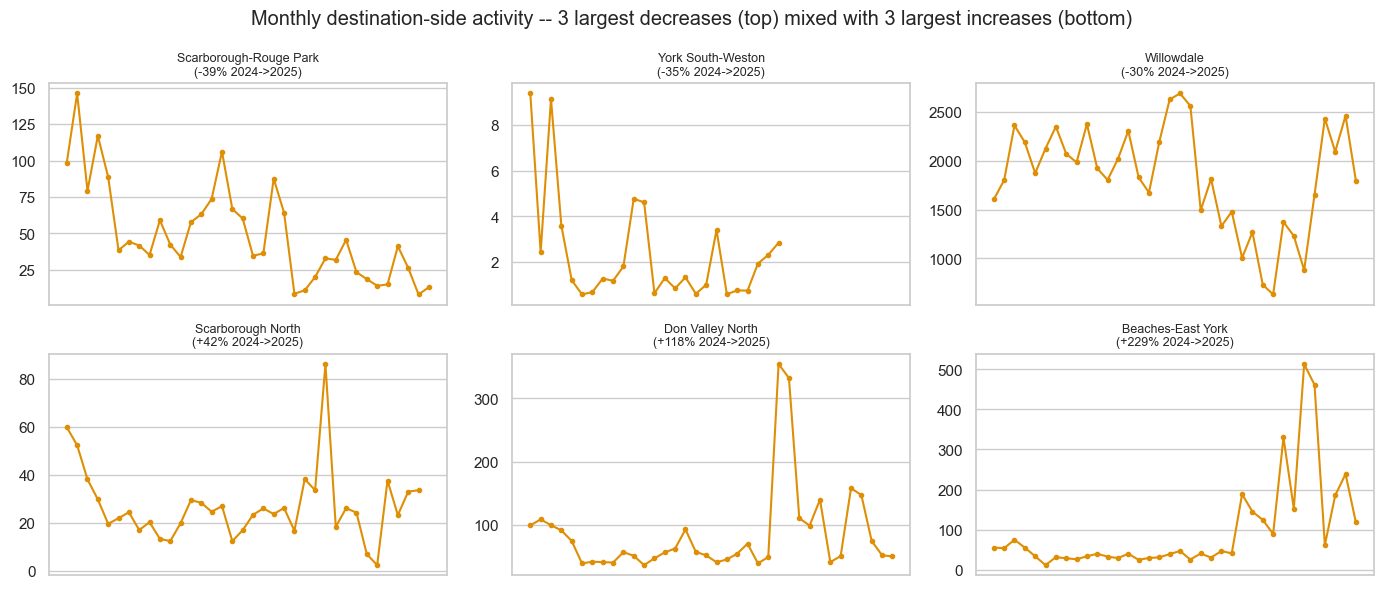

In [47]:
# CELL — Small multiples: monthly destination-side trend for the wards with the largest
# 2024->2025 swings in either direction (absolute counts, not indexed, so scale is visible)

biggest_movers = pd.concat([year_totals_sorted.head(3), year_totals_sorted.tail(3)]).index

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for ax, ward in zip(axes.flat, biggest_movers):
    series = dest_monthly[dest_monthly["dest_ward"] == ward].set_index("year_month")["normalized_raw_stop_count"].sort_index()
    ax.plot(range(len(series)), series.values, marker=".", color=PALETTE[1])
    ax.set_title(f"{ward}\n({year_totals.loc[ward, 'pct_change_2024_to_2025']:+.0%} 2024->2025)", fontsize=9)
    ax.set_xticks([])
plt.suptitle("Monthly destination-side activity -- 3 largest decreases (top) mixed with 3 largest increases (bottom)")
plt.tight_layout()
plt.show()

In [48]:
# CELL — Are these swings driven by one institution, or spread across a ward's venues?

movers_check = ward_comparison.set_index("ward_name").loc[biggest_movers, ["n_venues_in_ward", "venue_conc_top1"]]
movers_check["pct_change_2024_to_2025"] = year_totals.loc[biggest_movers, "pct_change_2024_to_2025"]
print("Venue count and top-venue concentration for the biggest movers:")
print(movers_check.round(2).to_string())
print("\nA ward with n_venues_in_ward <= 2 and/or venue_conc_top1 close to 1.0 has its year-over-year")
print("swing driven almost entirely by ONE venue's own trajectory, not a broad ward-level shift.")

Venue count and top-venue concentration for the biggest movers:
                        n_venues_in_ward  venue_conc_top1  pct_change_2024_to_2025
dest_ward                                                                         
Scarborough-Rouge Park                 1             1.00                    -0.39
York South-Weston                      1             1.00                    -0.35
Willowdale                             2             1.00                    -0.30
Scarborough North                      2             0.63                     0.42
Don Valley North                       1             1.00                     1.18
Beaches-East York                      3             0.52                     2.29

A ward with n_venues_in_ward <= 2 and/or venue_conc_top1 close to 1.0 has its year-over-year
swing driven almost entirely by ONE venue's own trajectory, not a broad ward-level shift.


In [49]:
# CELL — Selection effects: does restricting to a CONSISTENT venue panel (present in every
# month of both years) change the citywide 2024->2025 picture?

months_2024 = set(vs_all.loc[vs_all["year_month"] // 100 == 2024, "year_month"])
months_2025 = set(vs_all.loc[vs_all["year_month"] // 100 == 2025, "year_month"])
venue_month_counts = vs_all[vs_all["year_month"].isin(months_2024 | months_2025)].groupby("venue_id")["year_month"].nunique()
consistent_panel = venue_month_counts[venue_month_counts == len(months_2024 | months_2025)].index

print(f"Venues present in EVERY month of 2024+2025: {len(consistent_panel)} of {vs_all['venue_id'].nunique()}")

full_sample_change = (vs_all.loc[vs_all['year_month']//100==2025,'normalized_raw_stop_count'].sum() /
                       vs_all.loc[vs_all['year_month']//100==2024,'normalized_raw_stop_count'].sum() - 1)
panel_sample = vs_all[vs_all["venue_id"].isin(consistent_panel)]
panel_change = (panel_sample.loc[panel_sample['year_month']//100==2025,'normalized_raw_stop_count'].sum() /
                 panel_sample.loc[panel_sample['year_month']//100==2024,'normalized_raw_stop_count'].sum() - 1)

print(f"Citywide 2024->2025 change, full sample (105 venues, incl. those missing some months): {full_sample_change:+.1%}")
print(f"Citywide 2024->2025 change, consistent panel only ({len(consistent_panel)} venues):        {panel_change:+.1%}")

Venues present in EVERY month of 2024+2025: 75 of 105
Citywide 2024->2025 change, full sample (105 venues, incl. those missing some months): -9.4%
Citywide 2024->2025 change, consistent panel only (75 venues):        -9.7%


**Finding:** citywide destination-side activity fell modestly from 2024 to 2025 (~9-10%,
essentially unchanged whether we use the full sample or a consistent 75-venue panel present
in every month of both years -- so this is not a panel-composition artifact). The
ward-level swings are much larger and, for most of the biggest movers, driven almost
entirely by a single dominant venue (`venue_conc_top1` at or near 1.0) -- e.g. Willowdale's
-30% is Meridian Arts Centre's own trajectory, not a broad shift across multiple venues.
The origin-side geohash6-to-ward mapping (built here, not reused from all-period shares)
covers 99.3% of home-attributed activity, confirming it is usable for further monthly
origin-ward analysis if needed.

**Interpretation:** ward-level activity trends in this sample are largely institution-level
stories, not neighbourhood-level ones, for any ward with only 1-2 included venues --
councillors should read a single ward's year-over-year change as being about that specific
venue's programming/attendance pattern, not a verdict on the ward's cultural health broadly.
**What this does not show:** the cause of any single venue's change (programming, funding,
closures, or simply sample noise) -- that would need venue-level records this notebook
doesn't have.

### E. Public infrastructure and participation conditions

This section is deliberately the most tentative: census commuting data describes travel
**to work**, not to an arts venue; a straight-line home-to-venue distance is not a measured
travel time or transit accessibility; and ward-level demographics never describe individual
visitors. We treat everything here as a plausible mechanism or follow-up question, and name
the smallest additional dataset that would actually test it.

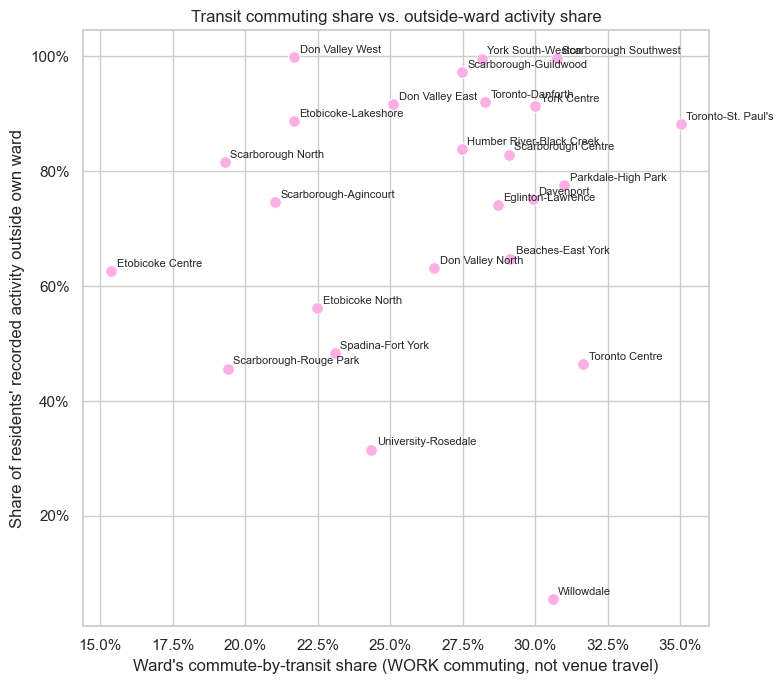

Correlation: 0.11. Follow-up data need: an actual transit-accessibility or travel-time-to-venue dataset (e.g. GTFS-based isochrones) would test this mechanism directly; work-commute mode share is only a loose proxy for a ward's general transit orientation.


In [50]:
# CELL — Ward transit-commute share vs. outside-ward activity share (labelled scatter)
# Reminder printed below: this is WORK commuting, not travel to an arts venue.

fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(data=ward_comparison, x="transit_commute_share", y="pct_outside_ward", s=70, ax=ax, color=PALETTE[6])
for _, row in ward_comparison.iterrows():
    ax.annotate(row["ward_name"], (row["transit_commute_share"], row["pct_outside_ward"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Ward's commute-by-transit share (WORK commuting, not venue travel)")
ax.set_ylabel("Share of residents' recorded activity outside own ward")
ax.set_title("Transit commuting share vs. outside-ward activity share")
plt.tight_layout()
plt.show()

corr_transit = ward_comparison[["transit_commute_share", "pct_outside_ward"]].corr().iloc[0, 1]
print(f"Correlation: {corr_transit:.2f}. Follow-up data need: an actual transit-accessibility or "
      f"travel-time-to-venue dataset (e.g. GTFS-based isochrones) would test this mechanism directly; "
      f"work-commute mode share is only a loose proxy for a ward's general transit orientation.")

In [51]:
# CELL — Evening/weekend patterns at a few selected venues, and citywide repeat-visitation
# and travel-distance context (all pre-computed, verified fields from venue_metrics.json)

selected = ["Meridian Arts Centre", "P.C. Ho Theatre", "Woodside Square Cinemas"]
rows = []
for v in venue_metrics_list:
    if v["venue_name"] in selected:
        rows.append({
            "venue_name": v["venue_name"],
            "weekday_pct": v["weekday_weekend_split"]["weekday_pct"],
            "weekend_pct": v["weekday_weekend_split"]["weekend_pct"],
            "nine_five_pct": v["daytime_evening_split"]["nine_five_pct"],
            "evening_pct": v["daytime_evening_split"]["evening_pct"],
        })
print("Weekday/weekend and daytime/evening split for selected venues (see Section 5 case studies):")
display(pd.DataFrame(rows))

# citywide travel-distance distribution, volume-weighted across all venues with data
dist_totals = Counter()
for v in venue_metrics_list:
    if v["travel_distance_distribution"]:
        for bucket, pct in v["travel_distance_distribution"].items():
            dist_totals[bucket] += pct
n_with_dist = sum(1 for v in venue_metrics_list if v["travel_distance_distribution"])
print(f"\nCitywide average travel-distance distribution (simple average across {n_with_dist} venues, straight-line, home geohash6 center to venue):")
for bucket, total in dist_totals.items():
    print(f"  {bucket:10s} {total/n_with_dist:.1f}%")

Weekday/weekend and daytime/evening split for selected venues (see Section 5 case studies):


,venue_name,weekday_pct,weekend_pct,nine_five_pct,evening_pct
0,Meridian Arts Centre,73.4632,26.5368,42.3858,57.6142
1,P.C. Ho Theatre,69.2759,30.7241,49.1228,50.8772
2,Woodside Square Cinemas,70.8383,29.1617,57.2727,42.7273



Citywide average travel-distance distribution (simple average across 105 venues, straight-line, home geohash6 center to venue):
  <1km       35.1%
  1-3km      22.2%
  3-10km     26.8%
  10km+      15.9%


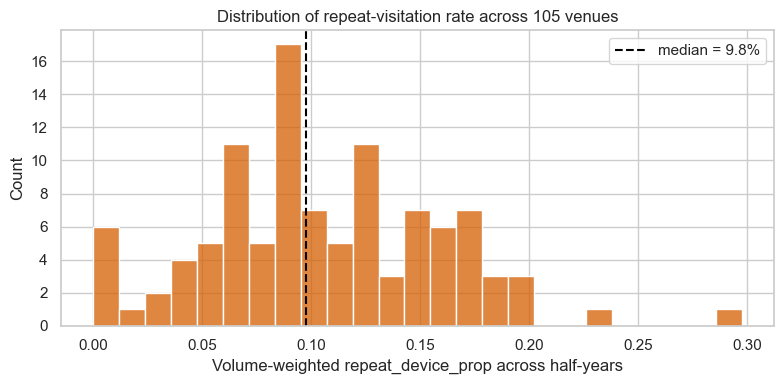

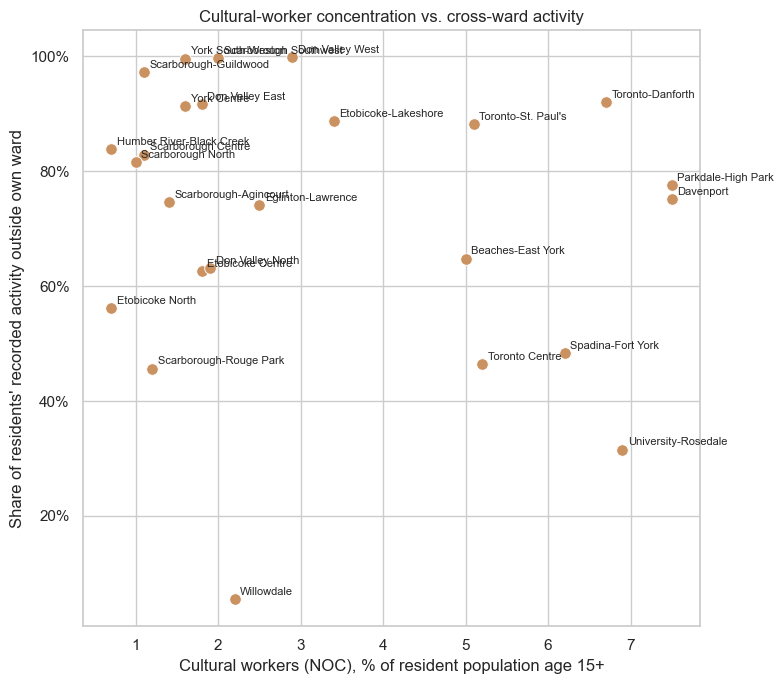

IMPORTANT: this compares WARD-LEVEL resident cultural-worker share with WARD-LEVEL mobility data --
it cannot tell us whether the cultural workers themselves are the ones generating the cross-ward activity.


In [52]:
# CELL — Citywide repeat-visitation distribution (within fixed half-years, per Section 1.3),
# and cultural-worker residence vs. cross-ward activity (linking back to Section 4C)

venue_repeat_weighted = rv_all.groupby("venue_id").apply(
    lambda g: (g["repeat_device_prop"] * g["unique_devices"]).sum() / g["unique_devices"].sum(),
    include_groups=False,
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(venue_repeat_weighted, bins=25, ax=ax, color=PALETTE[3])
ax.axvline(venue_repeat_weighted.median(), color="black", linestyle="--", label=f"median = {venue_repeat_weighted.median():.1%}")
ax.set_xlabel("Volume-weighted repeat_device_prop across half-years")
ax.set_title("Distribution of repeat-visitation rate across 105 venues")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(data=ward_comparison, x="labour_cultural_workers_pct", y="pct_outside_ward", s=70, ax=ax, color=PALETTE[5])
for _, row in ward_comparison.iterrows():
    ax.annotate(row["ward_name"], (row["labour_cultural_workers_pct"], row["pct_outside_ward"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Cultural workers (NOC), % of resident population age 15+")
ax.set_ylabel("Share of residents' recorded activity outside own ward")
ax.set_title("Cultural-worker concentration vs. cross-ward activity")
plt.tight_layout()
plt.show()
print("IMPORTANT: this compares WARD-LEVEL resident cultural-worker share with WARD-LEVEL mobility data --")
print("it cannot tell us whether the cultural workers themselves are the ones generating the cross-ward activity.")

**Assessment: this section surfaces plausible mechanisms, not conclusions.** None of the
correlations here are strong enough, or built on the right kind of data, to support a
direct infrastructure-investment claim on their own. The most useful outputs are the
follow-up questions and the smallest additional datasets that would test them:

| Plausible mechanism | What we have | What would actually test it |
|---|---|---|
| Transit access shapes cross-ward reach | Work-commute mode share (loose proxy) | GTFS-based travel-time isochrones from each ward to its venues |
| Evening/weekend programming widens access for commuters | Per-venue weekday/weekend, day-part splits | Same data, already usable -- see Section 5 case studies |
| Distance discourages visits | Straight-line home-to-venue distance buckets | Real travel time/mode (transit vs. car vs. walk) |
| Repeat visitors reflect a loyal local base | Half-year repeat-visitation rate | Individual-level linkage across half-years (not available; device IDs reset) |
| Cultural workers' own residence drives cross-ward activity | Ward-level correlation only | Survey or venue-level data on who is actually attending (not available in mobility data) |

---

## Section 5 — Modular ward case studies

Scarborough North and Willowdale are the mandated contrasts. Section 4C's quadrant and
combination checks surfaced two more genuinely useful comparisons: **Eglinton-Lawrence**
(the clearest "substantial cultural-workforce presence + very little included
infrastructure" case) and **Don Valley West** (an extreme outside-ward case -- 99.8% of
its residents' recorded activity leaves the ward -- that also sits in the high-worker/
low-venue quadrant, giving a second data point for the same story). Each case study uses
the same small helper so they stay consistent and swappable.

In [53]:
# CELL — Reusable case-study helper: provision + cultural-workforce + activity profile
# table, plus a destination breakdown chart. Used identically for all 4 wards below.

def ward_case_study(ward_name, top_n_dest=6):
    row = ward_comparison.set_index("ward_name").loc[ward_name]

    profile = pd.Series({
        "Population (2021, all ages)": f"{row['population']:,.0f}",
        "Included venues in ward": int(row["n_venues_in_ward"]),
        "Included venues per 100k": f"{row['venues_per_100k']:.2f}",
        "Share of activity within own ward": f"{row['pct_inside_ward']:.1%}",
        "Share of destination activity from outside ward": f"{row['dest_pct_from_outside']:.1%}" if pd.notna(row["dest_pct_from_outside"]) else "n/a (no venues)",
        "Concentration in top venue (of ward's received activity)": f"{row['venue_conc_top1']:.1%}" if pd.notna(row["venue_conc_top1"]) else "n/a",
        "Leading outside destination ward": row["top_outside_dest_ward"],
    })
    for m in NOC_NAICS_MEASURES:
        profile[NOC_NAICS_LABELS[m]] = f"{row[f'{m}_count']:,.0f} people ({row[f'{m}_pct']:.1f}%)"

    print(f"=== {ward_name} ===")
    display(profile.to_frame("Value"))

    dest_breakdown = ward_to_ward_activity[ward_to_ward_activity["origin_ward"] == ward_name].sort_values(VALUE_COL, ascending=False).head(top_n_dest)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors = [PALETTE[0] if is_self else PALETTE[3] for is_self in dest_breakdown["same_ward"]]
    ax.barh(dest_breakdown["dest_ward"], dest_breakdown["pct_of_origin"], color=colors)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel("Share of this ward's residents' recorded activity")
    ax.set_title(f"{ward_name}: top {top_n_dest} destination wards (own ward in blue)")
    plt.tight_layout()
    plt.show()

    return row

### Case study 1: Scarborough North

**Description:** Scarborough North's two included venues are P.C. Ho Theatre and Woodside
Square Cinemas. Its residents send the large majority of their recorded activity to venues
elsewhere -- but, as the chart below shows, "elsewhere" is mostly other Scarborough and
North York wards, not downtown.

=== Scarborough North ===


,Value
"Population (2021, all ages)","94,717"
Included venues in ward,2
Included venues per 100k,2.11
Share of activity within own ward,18.4%
Share of destination activity from outside ward,46.2%
Concentration in top venue (of ward's received activity),63.1%
Leading outside destination ward,Scarborough-Agincourt
Creatives (NOC),420 people (0.5%)
Cultural workers (NOC),787 people (1.0%)
Cultural industries (NAICS),739 people (0.9%)


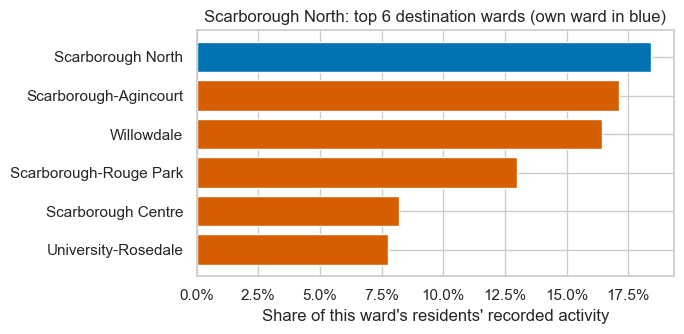

In [54]:
scarborough_north = ward_case_study("Scarborough North")

**Key comparison with other wards:** Scarborough North's outside-ward share (~81.6%) is
well above the citywide median, but its leading destinations (Scarborough-Agincourt,
Willowdale, Scarborough-Rouge Park, Scarborough Centre -- per the chart) form a regional
Scarborough/North-York network, not a downtown pull. This supports a **regional network
story rather than a downtown-only story**: residents already cross ward lines routinely
within their own broader area.

**Custom NOC/NAICS context:** Scarborough North does not lead any of the five custom
measures (it is not in the top-5-recurring list from Section 4C), but its counts are not
negligible either -- the standard census `labour_occupation_5_arts_culture` /
`labour_industry_71_arts` fields would tell the same "modest, unremarkable" story. This is
a case where the standard and custom measures agree, rather than one where the custom data
reveals a hidden population the standard fields miss.

**Possible councillor-facing implication:** investment or programming aimed at "Scarborough
North residents" may be more effective if designed around the existing regional network of
nearby Scarborough/North York venues, rather than assuming a single new facility inside the
ward's own boundary is the only lever. *(Interpretation -- separate from the finding.)*

**Main uncertainty:** we cannot tell whether residents choose these regional destinations
because they are genuinely preferred, or simply because no closer option exists within
the ward -- the mobility data alone cannot distinguish preference from lack of alternative.

### Case study 2: Willowdale

**Description:** Willowdale is the most self-contained ward in the study (94.5% of
residents' recorded activity stays within it), but that is almost entirely one venue's
effect: Meridian Arts Centre accounts for essentially all of the ward's received activity
(Section 2.3), and about a third of Meridian's own ward-mapped activity comes from
residents outside Willowdale.

Share of Meridian Arts Centre's ward-mapped activity from OUTSIDE Willowdale: 32.1%
=== Willowdale ===


,Value
"Population (2021, all ages)","118,218"
Included venues in ward,2
Included venues per 100k,1.69
Share of activity within own ward,94.5%
Share of destination activity from outside ward,32.1%
Concentration in top venue (of ward's received activity),99.6%
Leading outside destination ward,University-Rosedale
Creatives (NOC),"1,435 people (1.4%)"
Cultural workers (NOC),"2,234 people (2.2%)"
Cultural industries (NAICS),"1,490 people (1.4%)"


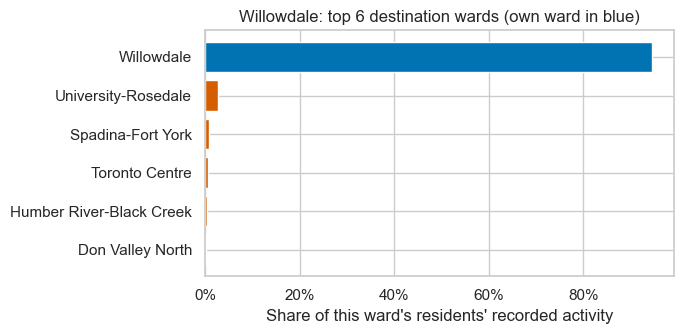

In [55]:
# CELL — Verify: what share of Meridian's own ward-mapped activity comes from outside Willowdale?

mer_ward_rows = ward_to_venue_activity[ward_to_venue_activity["venue_id"] == meridian_id]
mer_outside_share = mer_ward_rows.loc[~mer_ward_rows["is_home_ward"], VALUE_COL].sum() / mer_ward_rows[VALUE_COL].sum()
print(f"Share of Meridian Arts Centre's ward-mapped activity from OUTSIDE Willowdale: {mer_outside_share:.1%}")

willowdale = ward_case_study("Willowdale")

**Key comparison with other wards:** Willowdale is the only ward where `venue_conc_top1` is
effectively 1.0 combined with a within-ward share far above every other ward -- this is a
genuinely distinctive "anchor institution" pattern, not visible anywhere else in the data.
Willowdale's custom cultural-workforce measures are unremarkable (mid-pack on all five,
not a top-5 ward) -- the ward's activity story is about the venue, not about an unusually
large resident creative population.

**Testing the anchor-institution interpretation against data quality:** Section 2.3 already
flagged that Meridian's single largest home cell is essentially the block the venue itself
sits in, in a dense, mixed-use, transit-adjacent corridor -- so some of its "local" draw
could include nearby residents, workers, or transit/mall traffic rather than exclusively
committed arts visitors travelling specifically to attend something. Meridian's normal
stops/visit ratio, seasonal (not spiky) pattern, and above-average repeat-visit rate all
argue against a pure measurement artifact, but the concentration itself remains genuinely
ambiguous, not resolved.

**Possible councillor-facing implication:** a single well-attended anchor venue can carry a
ward's entire cultural-activity profile, for better (it demonstrates real sustained demand,
including from outside the ward) and for worse (the ward's apparent strength is fragile if
that one venue's circumstances change -- see Section 4D's -30% 2024-to-2025 swing for
Willowdale, which is Meridian's own trajectory). *(Interpretation, separate from the finding.)*

**Main uncertainty:** without clarifying whether nearby non-visitor devices (staff, transit
riders, mall shoppers) are inflating the "home" concentration, we cannot be fully confident
in how much of Willowdale's apparent self-containment is a true resident audience.

### Case study 3: Eglinton-Lawrence

**Description:** Eglinton-Lawrence combines one of the largest resident independent-artist
and cultural-worker populations of any low-provision ward with just a single included
venue -- the clearest single-ward version of the "artists already live here" argument
identified in Section 4C.

=== Eglinton-Lawrence ===


,Value
"Population (2021, all ages)","115,832"
Included venues in ward,1
Included venues per 100k,0.86
Share of activity within own ward,25.9%
Share of destination activity from outside ward,45.6%
Concentration in top venue (of ward's received activity),100.0%
Leading outside destination ward,Willowdale
Creatives (NOC),"1,374 people (1.4%)"
Cultural workers (NOC),"2,374 people (2.5%)"
Cultural industries (NAICS),"1,964 people (2.1%)"


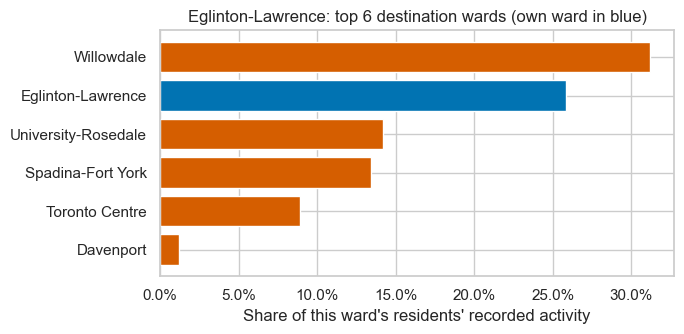

In [56]:
eglinton_lawrence = ward_case_study("Eglinton-Lawrence")

**Key comparison with other wards:** Eglinton-Lawrence sits in the high-cultural-worker /
low-venue-provision quadrant from Section 4C alongside Don Valley West and Willowdale, and
appears again in combination check (1) (substantial absolute artists/cultural workers +
<=1 included venue). Unlike Willowdale, it does **not** have a single dominant venue
already anchoring high within-ward activity -- so it is a genuinely different situation
from Willowdale's, despite both appearing in the same quadrant.

**Custom NOC/NAICS context:** this is one of the few wards where the "artists already live
here" argument holds up across multiple of the five custom definitions at once (not just
one measure cherry-picked to make the case) -- see its profile table above for the exact
counts and percentages under each definition.

**Possible councillor-facing implication:** of the four case-study wards, Eglinton-Lawrence
is the strongest candidate for the "resident cultural workforce as low-hanging fruit"
framing, precisely because it lacks Willowdale's confound of an existing large anchor venue.
*(Interpretation, separate from the finding.)*

**Main uncertainty:** we have no data on why this ward has only one included venue --
whether that reflects an actual scarcity of cultural spaces, a gap in TAC's venue list, or
some other cause -- and no evidence on whether Eglinton-Lawrence's cultural workers are
already commuting to work at venues elsewhere in the city.

### Case study 4: Don Valley West

**Description:** Don Valley West has the most extreme outside-ward share in the entire
study -- essentially all (99.8%) of residents' recorded activity is outside the ward -- and
also sits in the high-cultural-worker/low-venue quadrant from Section 4C, making it a
useful second data point alongside Eglinton-Lawrence.

=== Don Valley West ===


,Value
"Population (2021, all ages)","101,959"
Included venues in ward,2
Included venues per 100k,1.96
Share of activity within own ward,0.2%
Share of destination activity from outside ward,85.2%
Concentration in top venue (of ward's received activity),74.4%
Leading outside destination ward,Willowdale
Creatives (NOC),"1,342 people (1.6%)"
Cultural workers (NOC),"2,398 people (2.9%)"
Cultural industries (NAICS),"1,563 people (1.9%)"


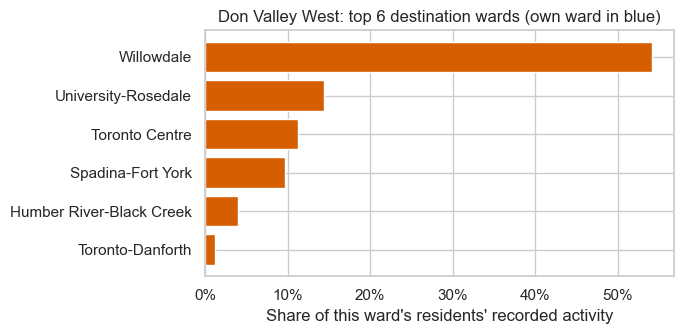

In [57]:
don_valley_west = ward_case_study("Don Valley West")

**Key comparison with other wards:** Don Valley West's 99.8% outside-ward share is far
beyond even Scarborough North's 81.6% or the citywide 52-61% range -- this ward's own
included venue(s) attract almost no recorded local activity at all, unlike Eglinton-Lawrence
which at least has some (~26%) within-ward share. The two wards make different points: Don
Valley West is closer to a genuine "cultural desert on its own terms" pattern, while
Eglinton-Lawrence has meaningfully more local activity already.

**Custom NOC/NAICS context:** Don Valley West's cultural-worker counts are comparable in
scale to Eglinton-Lawrence's, so the two wards together show the "artists already live
here, infrastructure is thin" pattern is not a one-off -- it recurs in at least two
distinct wards under multiple custom definitions.

**Possible councillor-facing implication:** the near-total outside-ward share is a strong
descriptive fact, but -- per Section 4B -- it does not by itself prove unmet local demand;
Don Valley West could simply be a small, geographically awkward ward for siting a venue
regardless of resident interest. *(Interpretation, separate from the finding.)*

**Main uncertainty:** with such an extreme share built on a small included-venue base, this
finding is highly sensitive to which one or two venues happen to be in the ward -- a single
venue closing or opening could swing this number dramatically, so we would not treat 99.8%
as a stable long-run characteristic of the ward without re-checking it periodically.

---

## Section 6 — Census relationships and interpretation

A small, hypothesis-led set of general census variables against one primary custom
measure (`labour_independent_artists_pct`, our closest "artists" proxy), followed by a
check of whether the same relationships hold across all five custom definitions and
whether one influential ward is driving them. With 25 wards we rely on labelled scatter
plots and effect sizes, not significance tests.

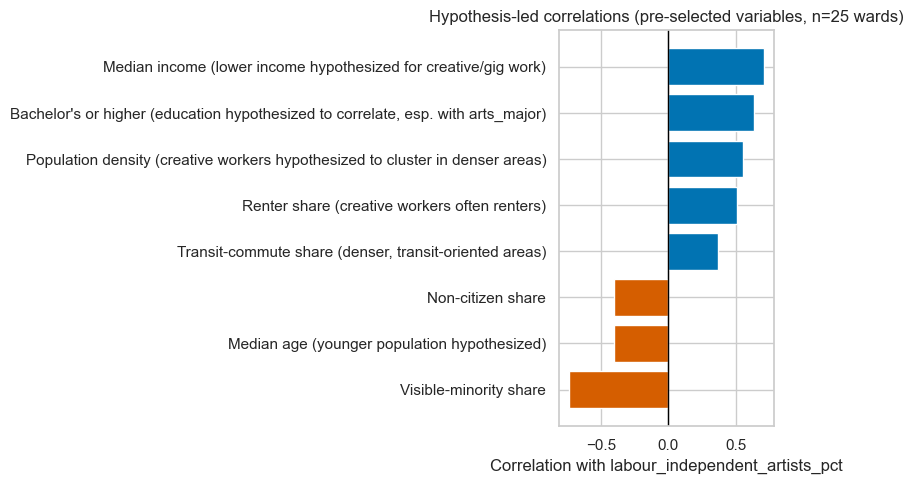

In [58]:
# CELL — Hypothesis-led correlations: labour_independent_artists_pct vs. a small,
# pre-selected set of general census variables (not an exhaustive fishing pass)

HYPOTHESIS_VARS = {
    "income_total_median": "Median income (lower income hypothesized for creative/gig work)",
    "renter_share": "Renter share (creative workers often renters)",
    "age_median": "Median age (younger population hypothesized)",
    "not_citizen_share": "Non-citizen share",
    "visible_minority_share": "Visible-minority share",
    "bachelor_or_higher_share": "Bachelor's or higher (education hypothesized to correlate, esp. with arts_major)",
    "transit_commute_share": "Transit-commute share (denser, transit-oriented areas)",
    "pop_density": "Population density (creative workers hypothesized to cluster in denser areas)",
}

PRIMARY_MEASURE = "labour_independent_artists_pct"
corrs = {label: ward_comparison[PRIMARY_MEASURE].corr(ward_comparison[var]) for var, label in HYPOTHESIS_VARS.items()}
corrs = pd.Series(corrs).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE[3] if v < 0 else PALETTE[0] for v in corrs]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel(f"Correlation with {PRIMARY_MEASURE}")
ax.set_title("Hypothesis-led correlations (pre-selected variables, n=25 wards)")
plt.tight_layout()
plt.show()

In [59]:
# CELL — Sensitivity to influential wards: leave-one-out on the strongest hypothesis-led
# correlation (whichever variable that is)

strongest_var_label = corrs.abs().idxmax()
strongest_var = [k for k, v in HYPOTHESIS_VARS.items() if v == strongest_var_label][0]
full_corr = ward_comparison[PRIMARY_MEASURE].corr(ward_comparison[strongest_var])

loo_corrs = []
for ward in ward_comparison["ward_name"]:
    subset = ward_comparison[ward_comparison["ward_name"] != ward]
    loo_corrs.append(subset[PRIMARY_MEASURE].corr(subset[strongest_var]))
loo_corrs = pd.Series(loo_corrs, index=ward_comparison["ward_name"])

print(f"Strongest hypothesis-led correlation: {PRIMARY_MEASURE} vs. {strongest_var} = {full_corr:.2f}")
print(f"Leave-one-out range across 25 wards: {loo_corrs.min():.2f} to {loo_corrs.max():.2f}")
print(f"Most influential ward (removing it shifts the correlation most): {loo_corrs.sub(full_corr).abs().idxmax()}")
print(f"\n{'Stable' if (loo_corrs.max() - loo_corrs.min()) < 0.15 else 'SENSITIVE'} to any single ward "
      f"(range {loo_corrs.max() - loo_corrs.min():.2f}) -- {'no single ward drives this relationship.' if (loo_corrs.max() - loo_corrs.min()) < 0.15 else 'treat this correlation with caution.'}")

Strongest hypothesis-led correlation: labour_independent_artists_pct vs. visible_minority_share = -0.74
Leave-one-out range across 25 wards: -0.80 to -0.71
Most influential ward (removing it shifts the correlation most): Etobicoke Centre

Stable to any single ward (range 0.10) -- no single ward drives this relationship.


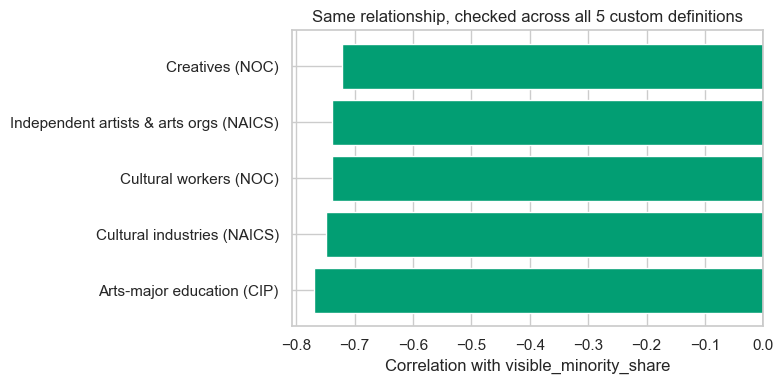

Arts-major education (CIP)                -0.77
Cultural industries (NAICS)               -0.75
Cultural workers (NOC)                    -0.74
Independent artists & arts orgs (NAICS)   -0.74
Creatives (NOC)                           -0.72

Range across definitions: -0.77 to -0.72 -- the conclusion is consistent across definitions.


In [60]:
# CELL — Does the strongest relationship hold across all 5 custom definitions, or is it
# specific to labour_independent_artists?

cross_def_corr = pd.Series({
    NOC_NAICS_LABELS[m]: ward_comparison[f"{m}_pct"].corr(ward_comparison[strongest_var]) for m in NOC_NAICS_MEASURES
}).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cross_def_corr.index, cross_def_corr.values, color=PALETTE[2])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel(f"Correlation with {strongest_var}")
ax.set_title(f"Same relationship, checked across all 5 custom definitions")
plt.tight_layout()
plt.show()

print(cross_def_corr.round(2).to_string())
print(f"\nRange across definitions: {cross_def_corr.min():.2f} to {cross_def_corr.max():.2f} -- "
      f"{'the conclusion is consistent across definitions.' if (cross_def_corr.max()-cross_def_corr.min()) < 0.25 else 'the conclusion DEPENDS on which definition is used -- flag this explicitly.'}")

**Finding, stated carefully:** the strongest hypothesis-led relationship we found is a
**negative** correlation between a ward's visible-minority population share and its
resident cultural-workforce concentration (-0.72 to -0.77 across all five custom
definitions, stable under leave-one-out -- no single ward drives it). This is a real,
robust pattern in this dataset, but it is a **ward-level (ecological) association**, not a
statement about any individual, and it should not be read as a claim about who can or
cannot be an artist. A ward-level correlation like this is consistent with several very
different underlying explanations that this data cannot distinguish between -- e.g.
housing cost and affordability patterns, where different waves of immigration have
historically settled in Toronto, occupational structures within specific communities, or
some combination -- and StatCan's own custom occupation/industry/education categories
(Section 1.2) are not designed to explain *why* a ward-level pattern like this exists.
**We flag this finding rather than build a headline story around it**: it needs care in
how (or whether) it is presented to councillors, and any programmatic implication drawn
from it should be checked against more targeted equity research, not this correlation
alone. The income, renter-share, age, and transit hypotheses were all weaker and are not
singled out here.

---

## Section 7 — Story recommendations

Five candidate angles, ranked by how well they held up under checking.

### 1. Cultural venues serve a citywide public, not just their own ward -- PURSUE

- **Headline:** "Your ward's residents are already using arts venues elsewhere in the
  city -- and other wards' residents are using yours."
- **Findings:** 52.0% of normalized ward-mapped activity is outside the resident's own
  ward citywide (60.8% excluding Meridian Arts Centre); 20 of 25 wards (19 excluding
  Meridian) have a majority-outside share (Section 2.4, 4A).
- **Strongest figure:** the sorted within/outside-ward stacked bar chart (Section 4A).
- **Ward/venue examples:** Willowdale (94.5% within, driven by Meridian Arts Centre) vs.
  Don Valley West (99.8% outside) as the two extremes.
- **Custom measure:** not applicable -- this angle is activity-based, not workforce-based.
- **Why it matters to councillors:** ward-level venue counts alone understate how many
  residents citywide actually rely on a given piece of cultural infrastructure.
- **Main limitation:** the citywide 52%/61% range depends on how one venue (Meridian) is
  handled; the activity-weighted and per-ward-distribution views can point differently.
  Both were checked and both are reported.
- **Additional evidence needed:** venue-level funding amounts, to connect cross-ward reach
  to funding equity specifically (only a yes/no funding flag exists today).
- **Verdict: PURSUE**, with the sensitivity range stated explicitly rather than a single number.

### 2. Cross-ward activity is a regional network, not a downtown-only pull -- PURSUE (qualified)

- **Headline:** "Suburban wards already connect to each other, not just downtown."
- **Findings:** of suburban wards' outside-ward activity, 43.1% goes to another suburban
  ward vs. 56.9% to the downtown core (Section 4B); venue provision and within-ward share
  correlate only moderately (r=0.42) with real exceptions in both directions.
- **Strongest figure:** the origin-normalized ward-to-ward heatmap (Section 4A) and the
  Scarborough North destination chart (Section 5).
- **Ward/venue examples:** Scarborough North -> Scarborough-Agincourt / Willowdale /
  Scarborough-Rouge Park / Scarborough Centre.
- **Custom measure:** not applicable.
- **Why it matters:** counters a downtown-centric assumption; suburban investment
  arguments can be framed around existing regional networks, not just single-ward facilities.
- **Main limitation:** we cannot tell preference from lack of local alternative.
- **Additional evidence needed:** resident survey data on venue choice reasons.
- **Verdict: PURSUE**, paired with angle 1 as supporting context, not a standalone headline.

### 3. Some wards already have a cultural workforce that outpaces their venue inventory -- PURSUE (as named exceptions)

- **Headline:** "Eglinton-Lawrence and Don Valley West already have artists and cultural
  workers living there -- just not many included venues."
- **Findings:** citywide, cultural-worker concentration and venue provision are actually
  positively correlated (pct-based r~0.67) -- so this is a specific-exceptions story, not a
  general pattern. Eglinton-Lawrence and Don Valley West both sit in the high-worker/
  low-venue quadrant and recur across combination checks (Section 4C, 5).
- **Strongest figure:** the quadrant plot (Section 4C).
- **Ward/venue examples:** Eglinton-Lawrence (1 venue; substantial artist/cultural-worker
  counts under multiple definitions) and Don Valley West (99.8% outside-ward activity,
  same quadrant).
- **Custom measure to anchor this:** `labour_independent_artists` (closest available
  "artists" proxy) for the headline count, cross-checked against `labour_cultural_workers`
  for the broader claim -- both name the same two wards.
- **Why it matters:** gives councillors in these wards a concrete, named resident
  population to point to, rather than an abstract equity argument.
- **Main limitation:** resident workforce presence is not proof of demand for a specific
  new facility or funding stream, and the exact NOC/NAICS/CIP codes behind these labels
  are not documented in this repo (Section 1.2).
- **Additional evidence needed:** direct engagement/consultation with resident artists in
  these two wards.
- **Verdict: PURSUE**, framed around the two named wards specifically, not citywide.

### 4. Willowdale shows what a single anchor venue can do -- and how fragile that looks -- QUALIFY

- **Headline:** "One venue can carry a whole ward's cultural profile -- for better and worse."
- **Findings:** Meridian Arts Centre is ~34.8% of citywide activity and drives Willowdale's
  94.5% within-ward share almost entirely (`venue_conc_top1` = 1.0); 32.1% of Meridian's own
  activity comes from outside Willowdale (a real regional draw); but Willowdale's
  destination-side activity fell ~30% from 2024 to 2025, entirely Meridian's own trajectory
  (Section 4D, 5).
- **Strongest figure:** Meridian's monthly trend chart (Section 2.3) and the Willowdale
  destination breakdown (Section 5).
- **Ward/venue examples:** Willowdale / Meridian Arts Centre.
- **Custom measure:** not applicable -- Willowdale's cultural-workforce measures are
  unremarkable; this is a venue story, not a resident-workforce story.
- **Why it matters:** illustrates both the upside (a well-run anchor venue draws a real
  regional audience) and the risk (a ward's apparent cultural strength can be one venue's
  fortunes, not a broad base) of concentrating investment in a single flagship.
- **Main limitation:** the home-origin concentration around Meridian is genuinely ambiguous
  (Section 2.3) -- some of its "local" draw could be proximity artifacts (staff, transit,
  mall traffic) rather than exclusively arts visitors, and we could not resolve this from
  the data available.
- **Additional evidence needed:** venue-level attendance records or a visitor survey to
  separate genuine local demand from device-proximity effects.
- **Verdict: QUALIFY** -- useful as a case study illustration, not as a standalone
  citywide claim.

### 5. Public-infrastructure mechanisms (transit, distance, evening programming) -- DROP as a headline, KEEP as follow-up questions

- **Headline (tentative only):** "Better transit access could widen who can reach existing venues."
- **Findings:** transit-commute share correlates weakly (r=0.11) with outside-ward
  activity; straight-line travel distance shows real variation across venues but is not a
  measured accessibility metric (Section 4E).
- **Strongest figure:** none rise to "strongest" -- all are exploratory scatterplots.
- **Ward/venue examples:** none specific enough to name.
- **Custom measure:** cultural-worker residence vs. cross-ward activity was checked and is
  ward-level only, not a demand signal.
- **Why it matters:** names the right follow-up questions even though it cannot answer them.
- **Main limitation:** every variable here is a loose proxy (work commuting, not venue
  travel; straight-line distance, not real accessibility); none of the sensitivity checks
  strengthen the case.
- **Additional evidence needed:** GTFS-based travel-time isochrones, or real
  accessibility/mode-choice data specific to arts-venue trips.
- **Verdict: DROP** as a headline; keep the data-need table (Section 4E) as a
  follow-up-research appendix if useful to TAC internally.

### Overall structure recommendations

**One coherent longer story:** "Toronto's cultural infrastructure already works as a
citywide network, not a ward-by-ward inventory" -- opening with angle 1 (cross-ward
reach), then angle 2 (it's a regional network, not just downtown), then angle 3 (specific
wards already have the resident cultural workforce to build on), closing with angle 4
(Willowdale/Meridian) as a cautionary illustration of what concentrated success and its
risks look like. Angle 5's follow-up questions can close the piece as "what we'd want to
know next."

**Alternative two-shorter-story split:**
- *Story A -- "Cultural venues already serve the whole city"*: angles 1 + 2 + the
  Willowdale/Meridian case study (angle 4), aimed at all councillors generally.
- *Story B -- "The untapped cultural workforce next door"*: angle 3 alone, built around
  the Eglinton-Lawrence and Don Valley West case studies, aimed specifically at councillors
  in lower-provision wards.

**Case studies that could be swapped for a different audience:** Scarborough North and
Willowdale are the most broadly illustrative (a suburban regional-network story and a
downtown-adjacent anchor-venue story) and should stay in either version. Eglinton-Lawrence
and Don Valley West are the swappable pair -- for an audience specifically interested in
the workforce argument, keep both; for a shorter general piece, either one alone
illustrates the point, with Eglinton-Lawrence as the stronger single example (it lacks
Willowdale's anchor-venue confound).

**Which custom measure should anchor "artists already live here":** `labour_independent_artists`
(NAICS: independent artists & arts organizations) -- it is the closest available proxy to
"artists specifically" among the five, and Eglinton-Lawrence and Don Valley West both lead
under this measure. **The conclusion is not sensitive to this choice**: Section 4C's
recurrence table and Section 5's case studies confirm the same two wards recur under
`labour_cultural_workers` as well, and Section 6's cross-definition check shows the
strongest general relationship we found (visible-minority share) is stable within
-0.72 to -0.77 across all five definitions. Where the five definitions disagree is at the
margins (the exact #4/#5 wards in a top-5 list), not on the headline wards used in this story.